In [1]:
import pandas as pd

# Load the dataset
file_path = r"C:\Users\hsafost4\OneDrive - The University of Liverpool\Master in Fintech\Tesis\Cleaned data -CREDIT_SCORE_FINAL.xlsx"

df = pd.read_excel(file_path)

# Display the Dataset

# Step 4: Display the first few rows to verify successful loading
display(df.head())

# Step 5: Check the number of rows and columns
print("\nDataset shape (rows, columns):")
print(df.shape)
print("\nColumn information:")
df.info()

,Ticker,Tkr & Exch,Short Name,S&P LT LC,Rating Scale,ABS Rating Scale,Sec Type,Curncy,Net Sales - 5 Yr Geo Gr,Mkt Cap,...,ROE,ROA - 5 Yr Geo Gr,ROA,EBITDA / Iexp,Cash Ratio,Debt/EBITDA,Net Dbt / EBITDA Adj,BEst P/E Nxt Yr,FCF Margin,BB 5Y Dflt Prob
0,NVDA US,NVDA US,NVIDIA CORP,AA,3,1,Common Stock,USD,66.898582,5.118058e+12,...,114.288067,32.039183,82.974465,516.185328,1.944968,0.077172,-0.629482,16.160312,44.770258,0.001313
1,0RIH LN,0RIH LN,ALPHABET INC-A,AA+,2,1,Common Stock,USD,17.154839,4.219927e+12,...,49.548547,13.329906,34.297588,208.586957,1.234542,0.672482,-0.701807,16.068936,18.187550,0.002645
2,MSFT US,MSFT US,MICROSOFT CORP,AAA,1,1,Common Stock,USD,14.571907,3.619434e+12,...,34.038627,0.129830,19.420798,65.794494,0.455164,0.641694,0.258893,20.750532,20.186597,0.002126
3,AMZN US,AMZN US,AMAZON.COM INC,AA,3,1,Common Stock,USD,13.178195,2.815228e+12,...,30.558338,6.637014,15.218417,70.244943,0.564340,1.313142,0.622985,21.135315,1.073336,0.005573
4,TSM US,TSM US,TAIWAN SEMIC-ADR,AA-,4,1,ADR,USD,23.251096,2.157158e+12,...,40.624113,2.652412,27.311519,212.134677,2.104564,0.377572,-0.869720,18.902192,28.519694,0.002473



Dataset shape (rows, columns):
(654, 26)

Column information:
<class 'pandas.DataFrame'>
RangeIndex: 654 entries, 0 to 653
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Ticker                   654 non-null    str    
 1   Tkr & Exch               654 non-null    str    
 2   Short Name               654 non-null    str    
 3   S&P LT LC                654 non-null    str    
 4   Rating Scale             654 non-null    int64  
 5   ABS Rating Scale         654 non-null    int64  
 6   Sec Type                 654 non-null    str    
 7   Curncy                   654 non-null    str    
 8   Net Sales - 5 Yr Geo Gr  654 non-null    float64
 9   Mkt Cap                  654 non-null    float64
 10  Tot Assets               654 non-null    float64
 11  Curr Ratio               654 non-null    float64
 12  Cntry Terrtry Of Rsk     654 non-null    str    
 13  Ind Sector               654

Exploratory Data Analysis

In [2]:
list(df.columns)

['Ticker',
 'Tkr & Exch',
 'Short Name',
 'S&P LT LC',
 'Rating Scale',
 'ABS Rating Scale',
 'Sec Type',
 'Curncy',
 'Net Sales - 5 Yr Geo Gr',
 'Mkt Cap',
 'Tot Assets',
 'Curr Ratio',
 'Cntry Terrtry Of Rsk',
 'Ind Sector',
 'Debt/Assets',
 '5Yr Avg ROE',
 'ROE',
 'ROA - 5 Yr Geo Gr',
 'ROA',
 'EBITDA / Iexp',
 'Cash Ratio',
 'Debt/EBITDA',
 'Net Dbt / EBITDA Adj',
 'BEst P/E Nxt Yr',
 'FCF Margin',
 'BB 5Y Dflt Prob']

In [3]:
frequency = df["S&P LT LC"].value_counts()
print(frequency)

S&P LT LC
BBB     130
BBB+    119
A-       90
BB+      65
BBB-     62
A        60
BB       44
A+       24
BB-      23
B+       16
AA-      10
AA        6
AA+       2
B         2
AAA       1
Name: count, dtype: int64


In [4]:
# Export clean table to Excel
frequency.to_excel('Frequency_Table.xlsx')
print("Table successfully exported to Excel!")

Table successfully exported to Excel!


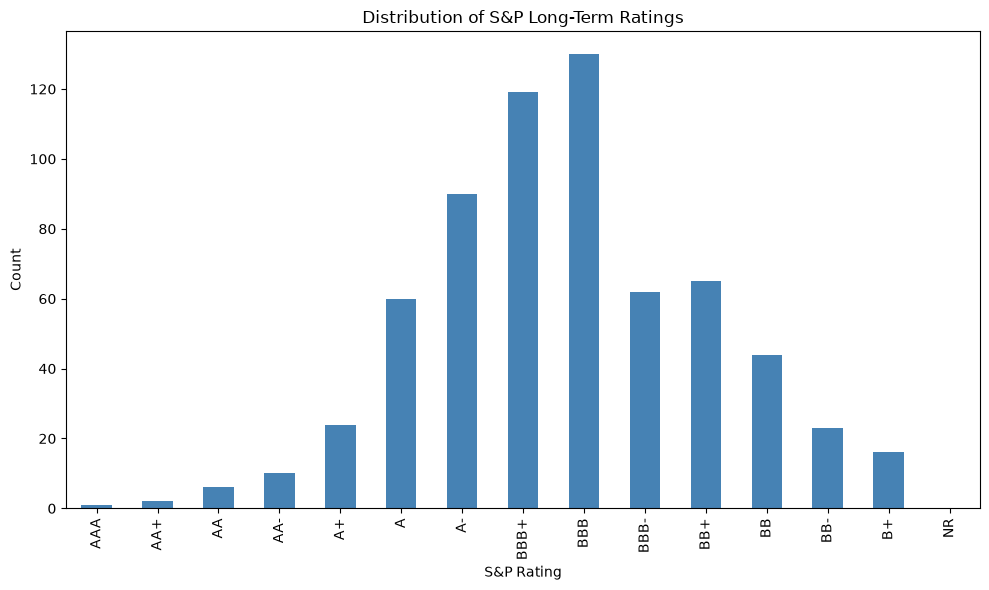

In [5]:
import matplotlib.pyplot as plt
import pandas as pd

# Define the desired order of S&P ratings
rating_order = ["AAA", "AA+", "AA", "AA-", "A+", "A", "A-", 
                "BBB+", "BBB", "BBB-", "BB+", "BB", "BB-", "B+", "NR"]


# Keep only the rows where the rating exists in your custom list
df = df[df["S&P LT LC"].isin(rating_order)].copy()

# Now the conversion will run without warnings
df["S&P LT LC"] = pd.Categorical(df["S&P LT LC"], categories=rating_order, ordered=True)

# Create the histogram based on value counts and the defined order
df["S&P LT LC"].value_counts().reindex(rating_order).plot(
    kind="bar", 
    color="steelblue",
    figsize=(10,6),
    title="Distribution of S&P Long-Term Ratings"
)
plt.xlabel("S&P Rating")
plt.ylabel("Count")
plt.tight_layout()
plt.grid(False)
plt.show()

In [6]:
# 1. Generate summary statistics with custom percentiles
stats = df.describe(percentiles=[0.05, 0.25, 0.50, 0.75, 0.95]).T

# --- EXCLUDE INDEX VARIABLES ---
stats = stats.drop(index=['Rating Scale', 'ABS Rating Scale'], errors='ignore')
# -------------------------------

# 2. Rename columns
rename_dict = {
    'count': 'N',
    'mean': 'Mean',
    'std': 'STDEV',
    '5%': 'P.05',
    '25%': 'P.25',
    '50%': 'Median',
    '75%': 'P.75',
    '95%': 'P.95'
}
stats = stats.rename(columns=rename_dict)

# 3. Reorder columns
column_order = ['Mean', 'STDEV', 'P.05', 'P.25', 'Median', 'P.75', 'P.95', 'N']
stats = stats[column_order]

# --- SCALE METRICS (Market Cap & Total Assets to Billions) ---
stat_cols = ['Mean', 'STDEV', 'P.05', 'P.25', 'Median', 'P.75', 'P.95']

stats.loc['Mkt Cap', stat_cols] = stats.loc['Mkt Cap', stat_cols] / 1e9
stats.loc['Tot Assets', stat_cols] = stats.loc['Tot Assets', stat_cols] / 1e6

stats = stats.rename(index={
    'Mkt Cap': 'Mkt Cap ($B)',
    'Tot Assets': 'Tot Assets ($MM)'
})
# -------------------------------------------------------------

# 4. Display formatted table
stats.style.format({
    'Mean': '{:.2f}',
    'STDEV': '{:.2f}',
    'P.05': '{:.2f}',
    'P.25': '{:.2f}',
    'Median': '{:.2f}',
    'P.75': '{:.2f}',
    'P.95': '{:.2f}',
    'N': '{:,.0f}'
})



,Mean,STDEV,P.05,P.25,Median,P.75,P.95,N
Net Sales - 5 Yr Geo Gr,8.02,7.82,-0.60,3.94,6.91,10.95,19.53,652
Mkt Cap ($B),81.68,350.09,1.65,6.46,19.00,49.68,213.31,652
Tot Assets ($MM),2.29,25.68,0.00,0.01,0.02,0.07,3.21,652
Curr Ratio,1.57,0.99,0.60,0.94,1.30,1.90,3.36,652
Debt/Assets,32.17,13.84,9.53,22.06,32.10,42.59,54.26,652
5Yr Avg ROE,22.30,39.71,6.14,9.84,15.35,23.67,51.76,652
ROE,21.60,39.25,3.15,9.30,14.27,22.15,53.62,652
ROA - 5 Yr Geo Gr,5.30,26.43,-21.72,-6.57,1.97,10.70,39.84,652
ROA,6.67,6.30,1.13,2.98,5.26,8.33,17.60,652
EBITDA / Iexp,29.61,212.26,3.53,5.69,9.81,17.51,69.23,652


In [7]:
# Export clean table to Excel
stats.round(2).to_excel('descriptive_statistics_fixed_assets.xlsx')
print("Table successfully exported to Excel!")

Table successfully exported to Excel!


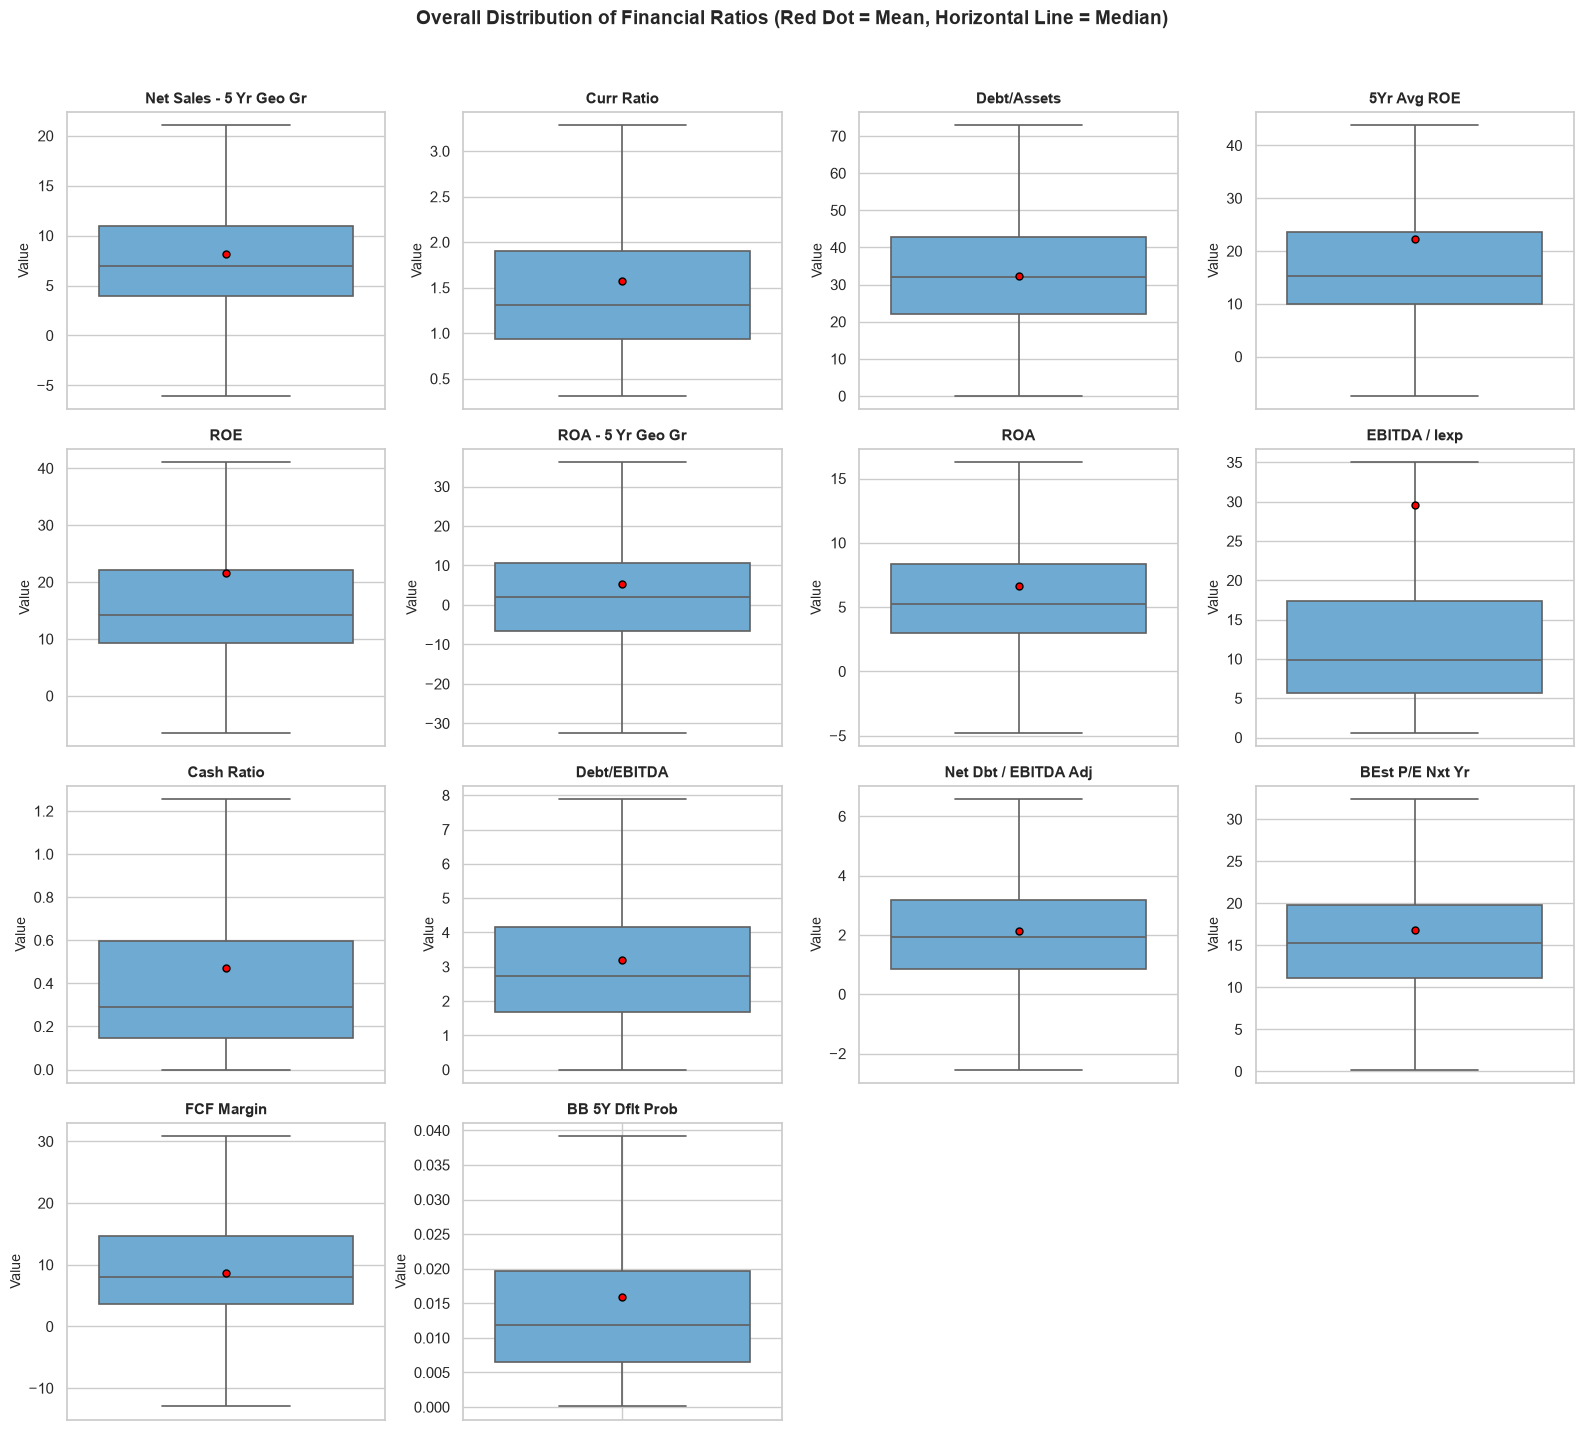

In [8]:
import math
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Load dataset
df = pd.read_excel('Cleaned data -CREDIT_SCORE_FINAL.xlsx')

# 2. Define list of financial ratios
ratio_cols = [
    'Net Sales - 5 Yr Geo Gr',
    'Curr Ratio',
    'Debt/Assets',
    '5Yr Avg ROE',
    'ROE',
    'ROA - 5 Yr Geo Gr',
    'ROA',
    'EBITDA / Iexp',
    'Cash Ratio',
    'Debt/EBITDA',
    'Net Dbt / EBITDA Adj',
    'BEst P/E Nxt Yr',
    'FCF Margin',
    'BB 5Y Dflt Prob',
]

# 3. Setup grid layout
sns.set_theme(style='whitegrid')
n_cols = 4
n_rows = math.ceil(len(ratio_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3.5 * n_rows))
axes = axes.flatten()

# 4. Plot each ratio's overall distribution
for i, col in enumerate(ratio_cols):
    sns.boxplot(
        y=df[col],
        ax=axes[i],
        color='#5DADE2',
        showmeans=True,
        meanprops={
            'marker': 'o',
            'markerfacecolor': 'red',
            'markeredgecolor': 'black',
            'markersize': '5',
        },
        showfliers=False,  # Set to True to display extreme outlier points
        linewidth=1.2,
    )
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Value', fontsize=10)

# 5. Remove unused subplots
for j in range(len(ratio_cols), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(
    'Overall Distribution of Financial Ratios (Red Dot = Mean, Horizontal Line = Median)',
    fontsize=14,
    fontweight='bold',
    y=1.02,
)
plt.tight_layout()
plt.grid(True)
plt.show()

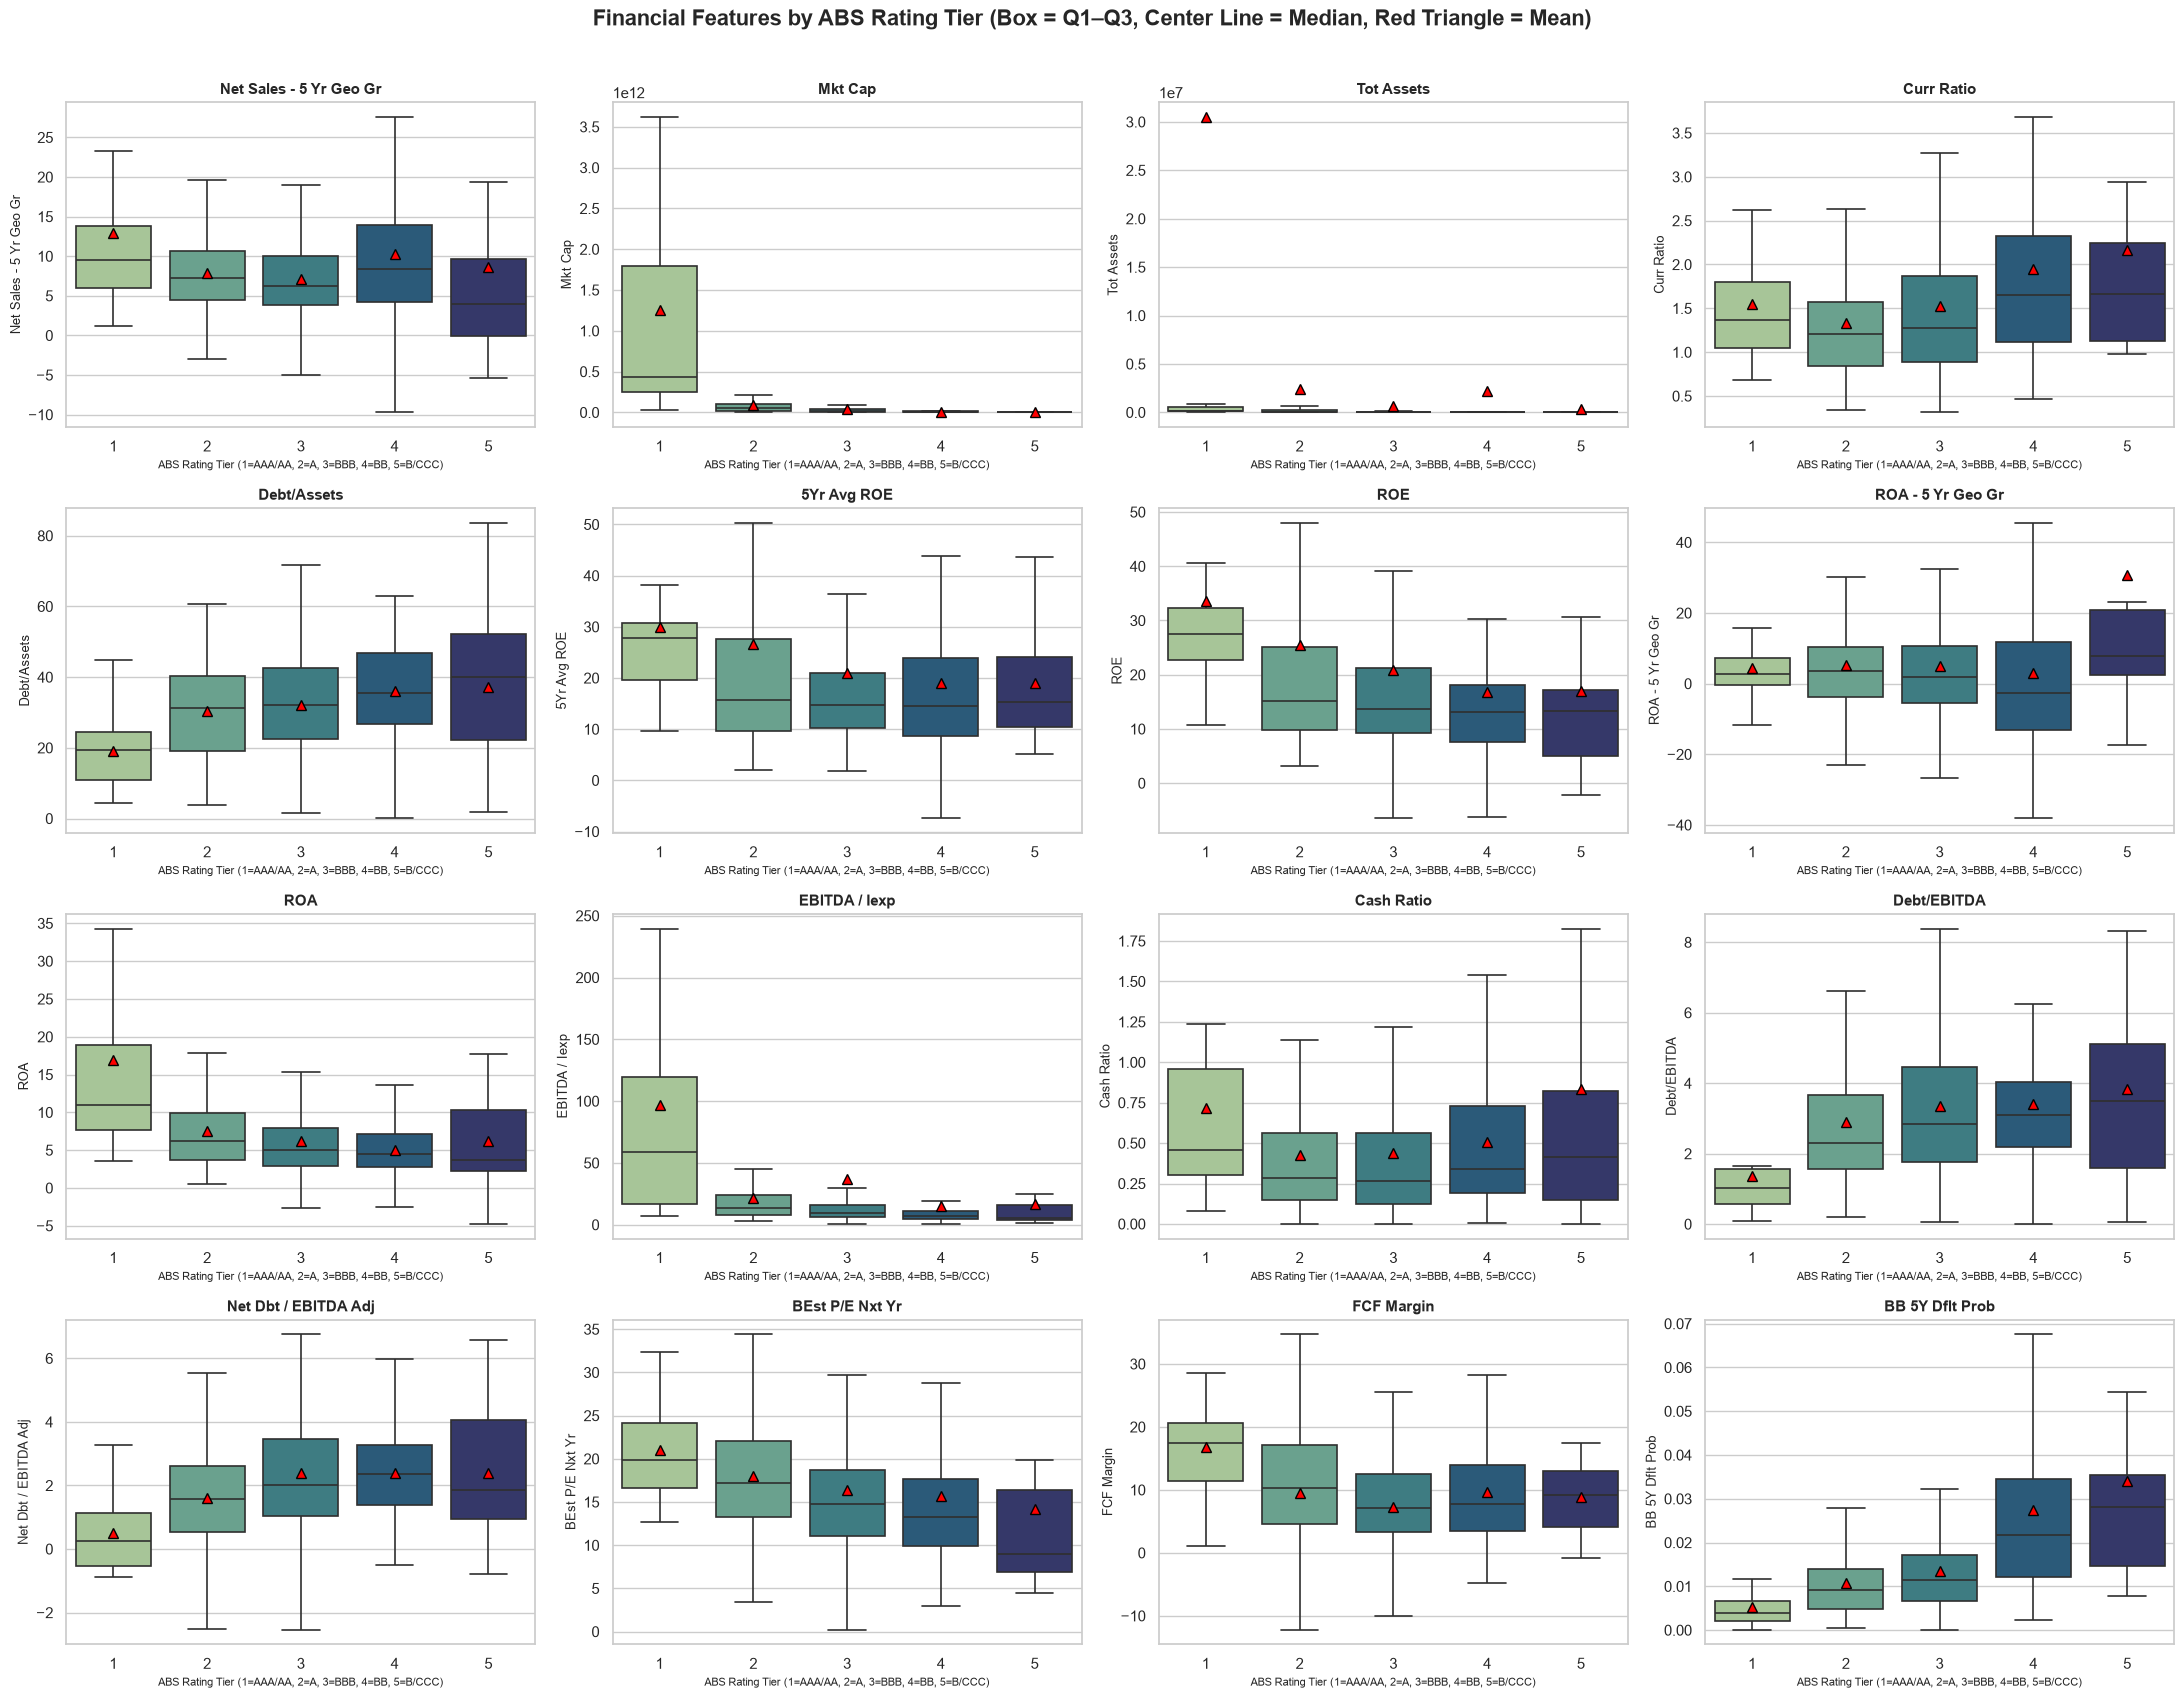

In [9]:
import math
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style='whitegrid')

# 1. Select all available numeric financial ratios and variables
# Excluding text identifiers, categories, and target rating scales
all_numeric_vars = [
    'Net Sales - 5 Yr Geo Gr',
    'Mkt Cap',
    'Tot Assets',
    'Curr Ratio',
    'Debt/Assets',
    '5Yr Avg ROE',
    'ROE',
    'ROA - 5 Yr Geo Gr',
    'ROA',
    'EBITDA / Iexp',
    'Cash Ratio',
    'Debt/EBITDA',
    'Net Dbt / EBITDA Adj',
    'BEst P/E Nxt Yr',
    'FCF Margin',
    'BB 5Y Dflt Prob',
]

# 2. Configure a dynamic grid layout
n_cols = 4
n_rows = math.ceil(len(all_numeric_vars) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(22, 4.2 * n_rows))
axes = axes.flatten()

# 3. Generate comparative boxplot for every feature
for idx, col in enumerate(all_numeric_vars):
  sns.boxplot(
      data=df,
      x='ABS Rating Scale',
      y=col,
      hue='ABS Rating Scale',  # Fixes Seaborn FutureWarning
      legend=False,
      ax=axes[idx],
      palette='crest',
      showmeans=True,  # Red triangle indicates the arithmetic mean
      meanprops={
          'marker': '^',
          'markerfacecolor': 'red',
          'markeredgecolor': 'black',
          'markersize': 7,
      },
      showfliers=False,  # Hides extreme outliers to keep the IQR and median clearly visible
      linewidth=1.2,
  )
  axes[idx].set_title(col, fontsize=11, fontweight='bold', pad=6)
  axes[idx].set_xlabel(
      'ABS Rating Tier (1=AAA/AA, 2=A, 3=BBB, 4=BB, 5=B/CCC)', fontsize=8
  )
  axes[idx].set_ylabel(col, fontsize=9)

# 4. Remove any unused empty subplots
for j in range(len(all_numeric_vars), len(axes)):
  fig.delaxes(axes[j])

plt.suptitle(
    'Financial Features by ABS Rating Tier (Box = Q1–Q3, Center Line = Median,'
    ' Red Triangle = Mean)',
    fontsize=16,
    fontweight='bold',
    y=1.01,
)
plt.tight_layout()
plt.savefig('all_variables_comparative_boxplots.png', dpi=300)
plt.show()

In [10]:
import pandas as pd

# 1. Scale Market Cap (Billions) and Total Assets (Millions)
# (Assumes raw values are in full units; adjust divisor if raw data is already in thousands/millions)
df['Mkt Cap ($B)'] = df['Mkt Cap'] / 1e9
df['Tot Assets ($M)'] = df['Tot Assets'] / 1e6

# Updated column list with scaled names
ratio_cols = [
    'Net Sales - 5 Yr Geo Gr', 'Mkt Cap ($B)', 'Tot Assets ($M)', 'Curr Ratio', 'Debt/Assets',
    '5Yr Avg ROE', 'ROE', 'ROA - 5 Yr Geo Gr', 'ROA', 'EBITDA / Iexp', 'Cash Ratio',
    'Debt/EBITDA', 'Net Dbt / EBITDA Adj', 'BEst P/E Nxt Yr', 'FCF Margin', 'BB 5Y Dflt Prob'
]

# 2. Group by only 'ABS Rating Scale' and round to 2 decimals
summary = (
    df.groupby('ABS Rating Scale')[ratio_cols]
    .agg(['mean', 'min', 'max'])
    .round(2)
)

# 3. Transpose
summary_t = summary.T

# 4. Console display formatting
pd.set_option('display.float_format', '{:.2f}'.format)
print(summary_t)

#Excel File

tier_map = {
    1: "1 (AAA/AA)",
    2: "2 (A)",
    3: "3 (BBB)",
    4: "4 (BB)",
    5: "5 (B/CCC)",
    6: "6 (CCC)"
}


# Map directly so grouping creates combined headers automatically
df['Rating Tier'] = df['ABS Rating Scale'].map(tier_map).fillna(df['ABS Rating Scale'])

summaryexcel = (
    df.groupby('Rating Tier')[ratio_cols]
    .agg(['mean', 'min', 'max'])
    .round(2)
)

summaryexcel.index.name = 'ABS Rating Tier (1=AAA/AA, 2=A, 3=BBB, 4=BB, 5=B/CCC)'

# 3. Transpose
summaryexcel_t = summaryexcel.T

# 5. Export to Excel with fixed 2-decimal formatting
summaryexcel_t.to_excel('Frequency_per_ABS_Rating.xlsx', float_format='%.2f')

ABS Rating Scale                   1       2       3      4      5
Net Sales - 5 Yr Geo Gr mean   12.95    7.82    7.07  10.33   8.64
                        min     1.20  -14.08  -23.17  -9.71  -5.39
                        max    66.90   53.13   34.01  80.65  82.78
Mkt Cap ($B)            mean 1253.01   95.90   36.74   9.91   1.91
                        min    26.82    0.56    0.56   0.37   0.31
                        max  5118.06 1704.69 1390.56 109.91   4.45
Tot Assets ($M)         mean   30.50    2.44    0.64   2.19   0.36
                        min     0.02    0.00    0.00   0.00   0.00
                        max   566.94  105.52  105.19 284.14   6.34
Curr Ratio              mean    1.55    1.34    1.52   1.94   2.17
                        min     0.68    0.34    0.31   0.47   0.98
                        max     3.91    4.79    5.31   9.44   5.56
Debt/Assets             mean   19.14   30.42   32.17  35.93  37.31
                        min     4.45    3.72    1.46   0.10   

In [11]:
# Drop the scaled columns now that they've been exported
df = df.drop(columns=['Mkt Cap ($B)', 'Tot Assets ($M)'])

# Confirm current columns
print(df.columns.tolist())

['Ticker', 'Tkr & Exch', 'Short Name', 'S&P LT LC', 'Rating Scale', 'ABS Rating Scale', 'Sec Type', 'Curncy', 'Net Sales - 5 Yr Geo Gr', 'Mkt Cap', 'Tot Assets', 'Curr Ratio', 'Cntry Terrtry Of Rsk', 'Ind Sector', 'Debt/Assets', '5Yr Avg ROE', 'ROE', 'ROA - 5 Yr Geo Gr', 'ROA', 'EBITDA / Iexp', 'Cash Ratio', 'Debt/EBITDA', 'Net Dbt / EBITDA Adj', 'BEst P/E Nxt Yr', 'FCF Margin', 'BB 5Y Dflt Prob', 'Rating Tier']


In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# Select only numeric financial ratio columns
ratio_cols = df.select_dtypes(include='number').columns

# Compute correlation matrix
corr_table = df[ratio_cols].corr()

# Display correlation table
corr_table

,Rating Scale,ABS Rating Scale,Net Sales - 5 Yr Geo Gr,Mkt Cap,Tot Assets,Curr Ratio,Debt/Assets,5Yr Avg ROE,ROE,ROA - 5 Yr Geo Gr,ROA,EBITDA / Iexp,Cash Ratio,Debt/EBITDA,Net Dbt / EBITDA Adj,BEst P/E Nxt Yr,FCF Margin,BB 5Y Dflt Prob
Rating Scale,1.00,0.95,0.07,-0.34,-0.07,0.21,0.19,-0.09,-0.10,0.03,-0.25,-0.04,0.04,0.12,0.13,-0.12,-0.05,0.45
ABS Rating Scale,0.95,1.00,0.04,-0.31,-0.08,0.21,0.20,-0.07,-0.09,0.05,-0.23,-0.03,0.06,0.12,0.14,-0.11,-0.05,0.41
Net Sales - 5 Yr Geo Gr,0.07,0.04,1.00,0.25,0.02,0.11,-0.08,-0.02,-0.02,0.04,0.23,0.06,0.17,-0.05,-0.06,0.07,0.09,0.10
Mkt Cap,-0.34,-0.31,0.25,1.00,0.10,0.06,-0.16,0.05,0.10,0.04,0.54,0.08,0.17,-0.12,-0.14,0.12,0.16,-0.12
Tot Assets,-0.07,-0.08,0.02,0.10,1.00,0.02,-0.07,-0.02,-0.01,-0.00,0.07,0.02,0.04,-0.03,-0.05,-0.07,-0.01,0.06
Curr Ratio,0.21,0.21,0.11,0.06,0.02,1.00,-0.23,-0.02,-0.04,-0.05,0.25,0.18,0.66,-0.13,-0.18,0.02,0.16,0.14
Debt/Assets,0.19,0.20,-0.08,-0.16,-0.07,-0.23,1.00,0.19,0.19,-0.04,-0.25,-0.14,-0.24,0.41,0.52,-0.01,-0.20,0.24
5Yr Avg ROE,-0.09,-0.07,-0.02,0.05,-0.02,-0.02,0.19,1.00,0.88,-0.00,0.25,0.01,0.03,-0.08,-0.06,0.02,0.13,-0.05
ROE,-0.10,-0.09,-0.02,0.10,-0.01,-0.04,0.19,0.88,1.00,0.07,0.39,0.01,0.05,-0.12,-0.08,0.01,0.17,-0.10
ROA - 5 Yr Geo Gr,0.03,0.05,0.04,0.04,-0.00,-0.05,-0.04,-0.00,0.07,1.00,0.17,0.00,-0.00,-0.10,-0.04,0.01,0.09,-0.14


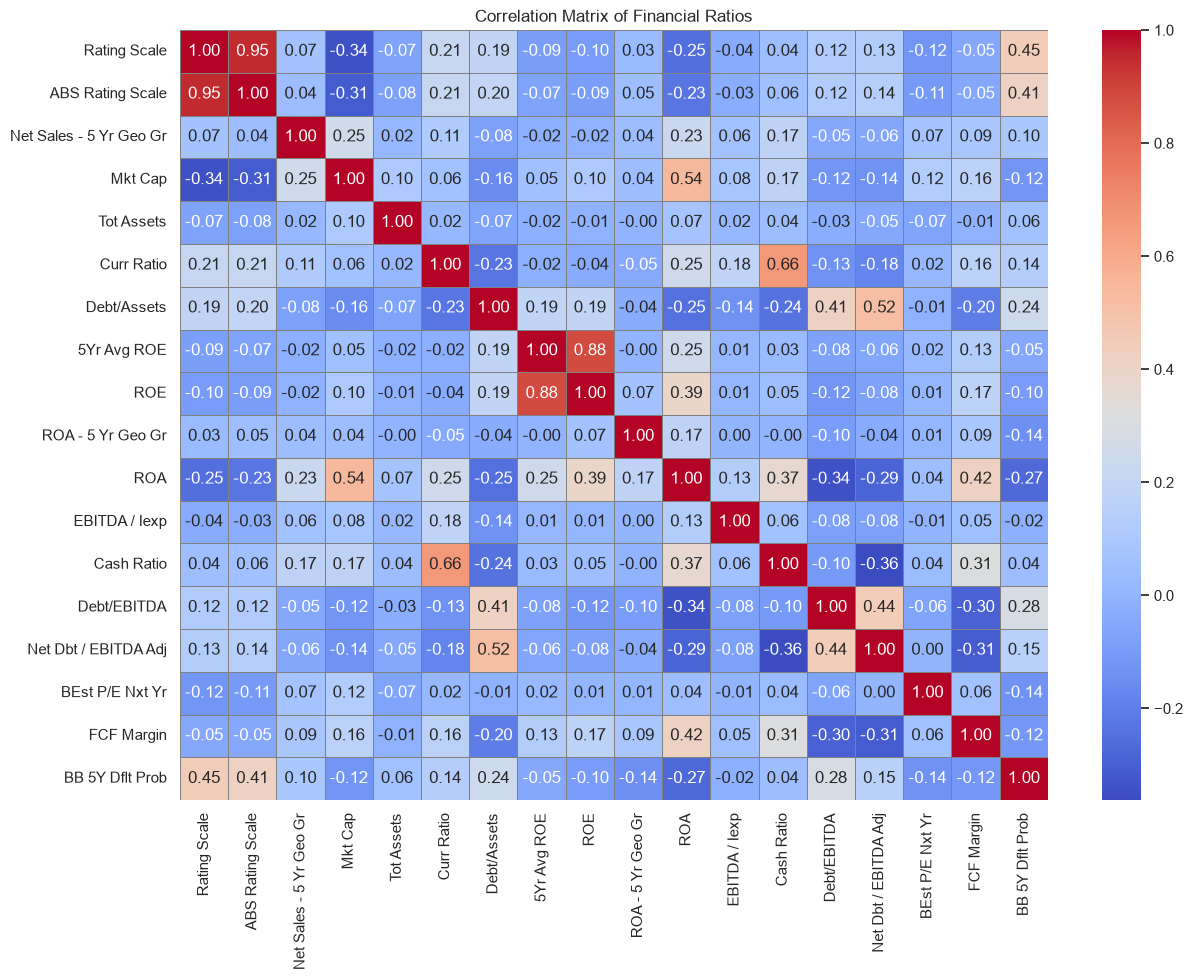

In [13]:
# Plot heatmap
plt.figure(figsize=(14,10))
sns.heatmap(corr_table, annot=True, cmap="coolwarm", fmt=".2f",
            linewidths=0.5, linecolor='gray')
plt.title("Correlation Matrix of Financial Ratios")
plt.show()

Prediction model

In [14]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

# -----------------------------------------------------------------------------
# 1. Define Dual Target Variables and Feature Space
# -----------------------------------------------------------------------------
# Target 1: Broad Ordinal Categories (1 = AAA/AA, 2 = A, 3 = BBB, 4 = BB, 5 = B/CCC)
y_broad = df['ABS Rating Scale'].copy()

# Target 2: Granular Continuous Notch Score (1.00 for AAA to 4.89 for B-)
y_granular = df['Rating Scale'].copy()

# Define columns to exclude: metadata, targets, and multicollinear financial ratios
cols_to_drop = [
    'Ticker', 'Tkr & Exch', 'Short Name', 'S&P LT LC', 'Tier Label',
    'Rating Scale', 'ABS Rating Scale',
    'Cntry Terrtry Of Rsk', 'Ind Sector', 'Sec Type', 'Curncy',
    'ROE', 'Cash Ratio', 'Net Dbt / EBITDA Adj'
]

X = df.drop(columns=[c for c in cols_to_drop if c in df.columns]).copy()
X = X.select_dtypes(include=[np.number])

# -----------------------------------------------------------------------------
# 2. Log-Transform Monetary Size Predictors
# -----------------------------------------------------------------------------
log_cols = ['Mkt Cap', 'Tot Assets']
for col in log_cols:
    if col in X.columns:
        X[col] = np.log1p(X[col])

# Remaining non-size continuous financial ratios
ratio_cols = [c for c in X.columns if c not in log_cols]

# -----------------------------------------------------------------------------
# 3. Stratified 80/20 Train/Test Split (Preserving Tier Proportions)
# -----------------------------------------------------------------------------
X_train, X_test, y_train_b, y_test_b, y_train_g, y_test_g = train_test_split(
    X, y_broad, y_granular, test_size=0.20, random_state=42, stratify=y_broad
)

# -----------------------------------------------------------------------------
# 4. Leak-Free Scaling via RobustScaler (Fit on Train Only)
# -----------------------------------------------------------------------------
scaler = RobustScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[ratio_cols] = scaler.fit_transform(X_train[ratio_cols])
X_test_scaled[ratio_cols] = scaler.transform(X_test[ratio_cols])

print("=" * 65)
print("DATA PREPARATION & PIPELINE DIAGNOSTICS")
print("=" * 65)
print(f"Total features in model ({X.shape[1]}): {X.columns.tolist()}")
print(f"Scaled continuous ratios ({len(ratio_cols)}): {ratio_cols}")
print(f"Training observations: {X_train_scaled.shape[0]} rows")
print(f"Testing observations:  {X_test_scaled.shape[0]} rows")

DATA PREPARATION & PIPELINE DIAGNOSTICS
Total features in model (13): ['Net Sales - 5 Yr Geo Gr', 'Mkt Cap', 'Tot Assets', 'Curr Ratio', 'Debt/Assets', '5Yr Avg ROE', 'ROA - 5 Yr Geo Gr', 'ROA', 'EBITDA / Iexp', 'Debt/EBITDA', 'BEst P/E Nxt Yr', 'FCF Margin', 'BB 5Y Dflt Prob']
Scaled continuous ratios (11): ['Net Sales - 5 Yr Geo Gr', 'Curr Ratio', 'Debt/Assets', '5Yr Avg ROE', 'ROA - 5 Yr Geo Gr', 'ROA', 'EBITDA / Iexp', 'Debt/EBITDA', 'BEst P/E Nxt Yr', 'FCF Margin', 'BB 5Y Dflt Prob']
Training observations: 523 rows
Testing observations:  131 rows


Broad ABS Rating Scale Experiment (Tiers 1 to 5)

CONFUSION MATRIX: ORDERED LOGISTIC REGRESSION (ABS RATING)


,AAA/AA (1),A (2),BBB (3),BB (4),B (5)
AAA/AA (1),1,3,0,0,0
A (2),0,18,15,2,0
BBB (3),1,8,40,13,0
BB (4),0,1,11,14,0
B (5),0,0,3,1,0


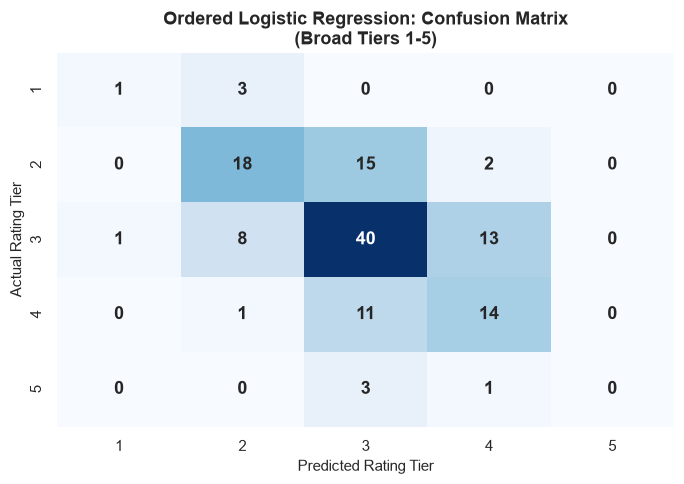

CLASSIFICATION REPORT: ORDERED LOGISTIC REGRESSION (ABS RATING)
              precision    recall  f1-score   support

  AAA/AA (1)       0.50      0.25      0.33         4
       A (2)       0.60      0.51      0.55        35
     BBB (3)       0.58      0.65      0.61        62
      BB (4)       0.47      0.54      0.50        26
       B (5)       0.00      0.00      0.00         4

    accuracy                           0.56       131
   macro avg       0.43      0.39      0.40       131
weighted avg       0.54      0.56      0.55       131

=== Comprehensive Metrics Table: Ordered Logistic Regression ===


,Metric,Score
0,Accuracy,55.73%
1,Balanced Accuracy,38.96%
2,Macro Precision,42.93%
3,Macro Recall,38.96%
4,Macro F1-Score,39.96%
5,Weighted Precision,54.26%
6,Weighted Recall,55.73%
7,Weighted F1-Score,54.64%


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.miscmodels.ordinal_model import OrderedModel
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    balanced_accuracy_score, precision_score, recall_score, f1_score
)

# 1. Fit Ordered Logistic Regression (Cumulative Logit)
ord_logit = OrderedModel(y_train_b, X_train_scaled, distr='logit', hasconst=False)
ord_results = ord_logit.fit(method='bfgs', maxiter=1000, disp=False)

# 2. Predict Probabilities & Map to Discrete Tiers
prob_preds_ord = ord_results.predict(X_test_scaled)
ordered_classes = np.sort(y_train_b.unique())
y_pred_ord_b = ordered_classes[np.argmax(prob_preds_ord.values, axis=1)]

# 3. Confusion Matrix & Heatmap
tier_names = ['AAA/AA (1)', 'A (2)', 'BBB (3)', 'BB (4)', 'B (5)']
tier_labels = [1, 2, 3, 4, 5]
cm_ord_b = confusion_matrix(y_test_b, y_pred_ord_b, labels=tier_labels)

print("=" * 65)
print("CONFUSION MATRIX: ORDERED LOGISTIC REGRESSION (ABS RATING)")
print("=" * 65)
display(pd.DataFrame(cm_ord_b, index=tier_names, columns=tier_names))

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm_ord_b, annot=True, fmt='d', cmap='Blues', cbar=False,
    xticklabels=tier_labels, yticklabels=tier_labels,
    annot_kws={'size': 13, 'weight': 'bold'}
)
plt.title('Ordered Logistic Regression: Confusion Matrix\n(Broad Tiers 1-5)', fontsize=13, fontweight='bold')
plt.xlabel('Predicted Rating Tier', fontsize=11)
plt.ylabel('Actual Rating Tier', fontsize=11)
plt.tight_layout()
plt.show()

# 4. Classification Report
print("=" * 65)
print("CLASSIFICATION REPORT: ORDERED LOGISTIC REGRESSION (ABS RATING)")
print("=" * 65)
print(classification_report(y_test_b, y_pred_ord_b, labels=tier_labels, target_names=tier_names, zero_division=0))

# 5. Metrics Table
acc_ord_b = accuracy_score(y_test_b, y_pred_ord_b)
bacc_ord_b = balanced_accuracy_score(y_test_b, y_pred_ord_b)
m_prec_ord_b = precision_score(y_test_b, y_pred_ord_b, labels=tier_labels, average='macro', zero_division=0)
m_rec_ord_b = recall_score(y_test_b, y_pred_ord_b, labels=tier_labels, average='macro', zero_division=0)
m_f1_ord_b = f1_score(y_test_b, y_pred_ord_b, labels=tier_labels, average='macro', zero_division=0)
w_prec_ord_b = precision_score(y_test_b, y_pred_ord_b, labels=tier_labels, average='weighted', zero_division=0)
w_rec_ord_b = recall_score(y_test_b, y_pred_ord_b, labels=tier_labels, average='weighted', zero_division=0)
w_f1_ord_b = f1_score(y_test_b, y_pred_ord_b, labels=tier_labels, average='weighted', zero_division=0)

metrics_ord_b_df = pd.DataFrame({
    'Metric': [
        'Accuracy', 'Balanced Accuracy', 'Macro Precision', 'Macro Recall',
        'Macro F1-Score', 'Weighted Precision', 'Weighted Recall', 'Weighted F1-Score'
    ],
    'Score': [
        f"{acc_ord_b * 100:.2f}%", f"{bacc_ord_b * 100:.2f}%", f"{m_prec_ord_b * 100:.2f}%",
        f"{m_rec_ord_b * 100:.2f}%", f"{m_f1_ord_b * 100:.2f}%", f"{w_prec_ord_b * 100:.2f}%",
        f"{w_rec_ord_b * 100:.2f}%", f"{w_f1_ord_b * 100:.2f}%"
    ]
})

print("=== Comprehensive Metrics Table: Ordered Logistic Regression ===")
display(metrics_ord_b_df)

In [16]:
# Extract parameters, robust standard errors, z-statistics, p-values, and 95% confidence intervals
params = ord_results.params
conf = ord_results.conf_int()
bse = ord_results.bse
pvalues = ord_results.pvalues

excel_display_broad = pd.DataFrame({
    'Variable': params.index,
    'Coefficient (Beta)': params.values,
    'Std. Error': bse.values,
    'z-Statistic': (params / bse).values,
    'p-value': pvalues.values,
    '[95% Conf. Interval Lower]': conf[0].values,
    '[95% Conf. Interval Upper]': conf[1].values,
    'Odds Ratio (exp(-Beta))': np.exp(-params.values)
}).round(4)

print("=" * 80)
print("TRADITIONAL ECONOMETRIC REGRESSION DISPLAY: BROAD ABS RATING SCALE")
print("=" * 80)
display(excel_display_broad)

# Save to Excel
excel_display_broad.to_excel("econometric_table_ordered_logit_broad.xlsx", index=False)

TRADITIONAL ECONOMETRIC REGRESSION DISPLAY: BROAD ABS RATING SCALE


,Variable,Coefficient (Beta),Std. Error,z-Statistic,p-value,[95% Conf. Interval Lower],[95% Conf. Interval Upper],Odds Ratio (exp(-Beta))
0,Net Sales - 5 Yr Geo Gr,0.16,0.09,1.79,0.07,-0.02,0.34,0.85
1,Mkt Cap,-0.77,0.10,-7.37,0.00,-0.97,-0.56,2.16
2,Tot Assets,-0.47,0.07,-7.05,0.00,-0.60,-0.34,1.60
3,Curr Ratio,0.35,0.12,2.88,0.00,0.11,0.59,0.70
4,Debt/Assets,0.38,0.16,2.34,0.02,0.06,0.70,0.68
5,5Yr Avg ROE,-0.06,0.04,-1.65,0.10,-0.13,0.01,1.06
6,ROA - 5 Yr Geo Gr,0.21,0.06,3.64,0.00,0.10,0.33,0.81
7,ROA,-0.22,0.13,-1.76,0.08,-0.47,0.03,1.25
8,EBITDA / Iexp,-0.02,0.02,-1.01,0.31,-0.06,0.02,1.02
9,Debt/EBITDA,0.02,0.08,0.28,0.78,-0.13,0.18,0.98


Broad CART Classifier

CONFUSION MATRIX: CART CLASSIFIER (ABS RATING)


,AAA/AA (1),A (2),BBB (3),BB (4),B (5)
AAA/AA (1),2,2,0,0,0
A (2),4,27,0,3,1
BBB (3),2,39,1,16,4
BB (4),0,10,4,10,2
B (5),0,1,0,1,2


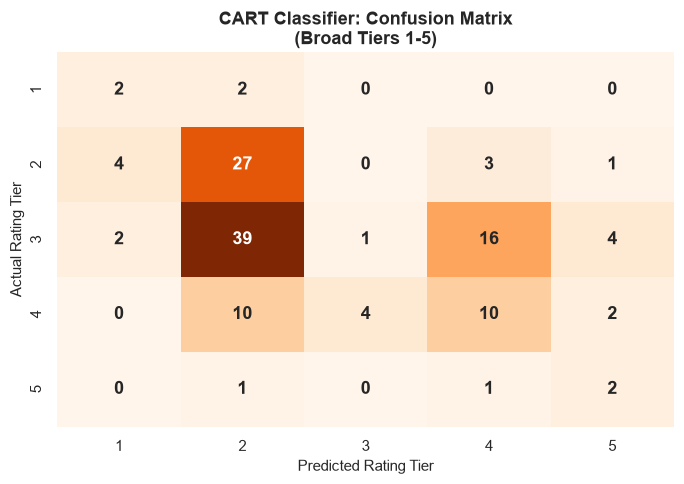

CLASSIFICATION REPORT: CART CLASSIFIER (ABS RATING)
              precision    recall  f1-score   support

  AAA/AA (1)       0.25      0.50      0.33         4
       A (2)       0.34      0.77      0.47        35
     BBB (3)       0.20      0.02      0.03        62
      BB (4)       0.33      0.38      0.36        26
       B (5)       0.22      0.50      0.31         4

    accuracy                           0.32       131
   macro avg       0.27      0.43      0.30       131
weighted avg       0.27      0.32      0.23       131

=== Comprehensive Metrics Table: CART Classifier ===


,Metric,Score
0,Accuracy,32.06%
1,Balanced Accuracy,43.44%
2,Macro Precision,26.95%
3,Macro Recall,43.44%
4,Macro F1-Score,30.03%
5,Weighted Precision,26.65%
6,Weighted Recall,32.06%
7,Weighted F1-Score,23.11%


In [17]:
from sklearn.tree import DecisionTreeClassifier

# 1. Fit CART Classifier
cart_clf = DecisionTreeClassifier(max_depth=4, class_weight='balanced', random_state=42)
cart_clf.fit(X_train_scaled, y_train_b)
y_pred_cart_b = cart_clf.predict(X_test_scaled)

# 2. Confusion Matrix & Heatmap
cm_cart_b = confusion_matrix(y_test_b, y_pred_cart_b, labels=tier_labels)

print("=" * 65)
print("CONFUSION MATRIX: CART CLASSIFIER (ABS RATING)")
print("=" * 65)
display(pd.DataFrame(cm_cart_b, index=tier_names, columns=tier_names))

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm_cart_b, annot=True, fmt='d', cmap='Oranges', cbar=False,
    xticklabels=tier_labels, yticklabels=tier_labels,
    annot_kws={'size': 13, 'weight': 'bold'}
)
plt.title('CART Classifier: Confusion Matrix\n(Broad Tiers 1-5)', fontsize=13, fontweight='bold')
plt.xlabel('Predicted Rating Tier', fontsize=11)
plt.ylabel('Actual Rating Tier', fontsize=11)
plt.tight_layout()
plt.show()

# 3. Classification Report
print("=" * 65)
print("CLASSIFICATION REPORT: CART CLASSIFIER (ABS RATING)")
print("=" * 65)
print(classification_report(y_test_b, y_pred_cart_b, labels=tier_labels, target_names=tier_names, zero_division=0))

# 4. Metrics Table
acc_cart_b = accuracy_score(y_test_b, y_pred_cart_b)
bacc_cart_b = balanced_accuracy_score(y_test_b, y_pred_cart_b)
m_prec_cart_b = precision_score(y_test_b, y_pred_cart_b, labels=tier_labels, average='macro', zero_division=0)
m_rec_cart_b = recall_score(y_test_b, y_pred_cart_b, labels=tier_labels, average='macro', zero_division=0)
m_f1_cart_b = f1_score(y_test_b, y_pred_cart_b, labels=tier_labels, average='macro', zero_division=0)
w_prec_cart_b = precision_score(y_test_b, y_pred_cart_b, labels=tier_labels, average='weighted', zero_division=0)
w_rec_cart_b = recall_score(y_test_b, y_pred_cart_b, labels=tier_labels, average='weighted', zero_division=0)
w_f1_cart_b = f1_score(y_test_b, y_pred_cart_b, labels=tier_labels, average='weighted', zero_division=0)

metrics_cart_b_df = pd.DataFrame({
    'Metric': [
        'Accuracy', 'Balanced Accuracy', 'Macro Precision', 'Macro Recall',
        'Macro F1-Score', 'Weighted Precision', 'Weighted Recall', 'Weighted F1-Score'
    ],
    'Score': [
        f"{acc_cart_b * 100:.2f}%", f"{bacc_cart_b * 100:.2f}%", f"{m_prec_cart_b * 100:.2f}%",
        f"{m_rec_cart_b * 100:.2f}%", f"{m_f1_cart_b * 100:.2f}%", f"{w_prec_cart_b * 100:.2f}%",
        f"{w_rec_cart_b * 100:.2f}%", f"{w_f1_cart_b * 100:.2f}%"
    ]
})

print("=== Comprehensive Metrics Table: CART Classifier ===")
display(metrics_cart_b_df)

HEAD-TO-HEAD COMPARISON: BROAD ABS RATING SCALE (5 TIERS)


,Metric,Ordered Logistic Regression,CART Classifier
0,Accuracy,55.73%,32.06%
1,Balanced Accuracy,38.96%,43.44%
2,Macro Precision,42.93%,26.95%
3,Macro Recall,38.96%,43.44%
4,Macro F1-Score,39.96%,30.03%
5,Weighted Precision,54.26%,26.65%
6,Weighted Recall,55.73%,32.06%
7,Weighted F1-Score,54.64%,23.11%


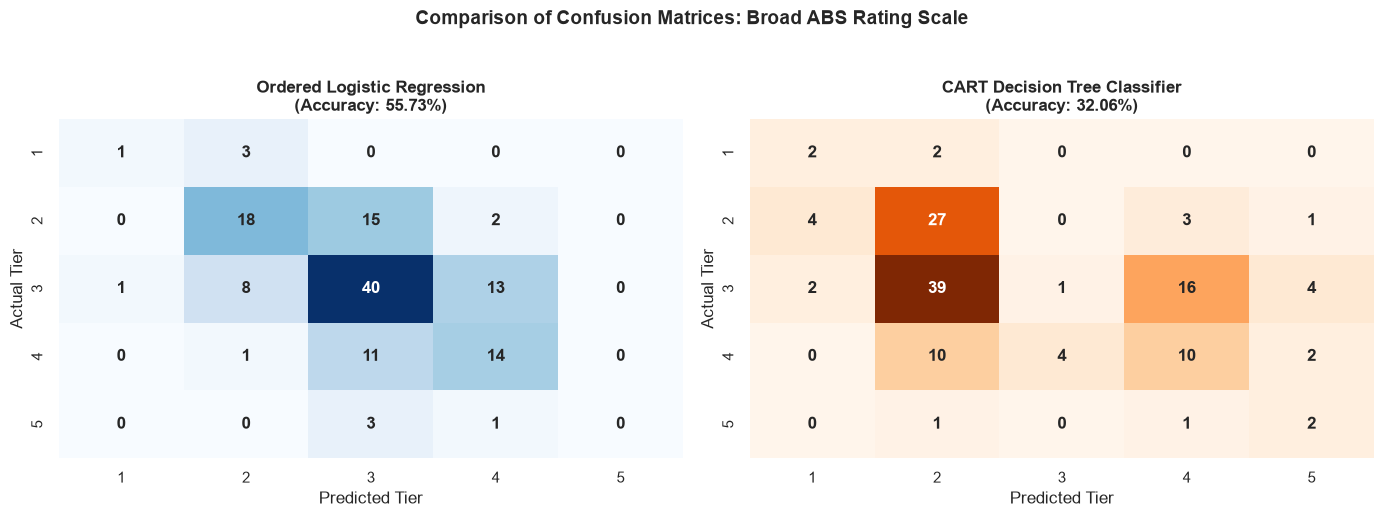

In [18]:
#Broad Tier Comparison
comp_broad_df = pd.DataFrame({
    'Metric': [
        'Accuracy', 'Balanced Accuracy', 'Macro Precision', 'Macro Recall',
        'Macro F1-Score', 'Weighted Precision', 'Weighted Recall', 'Weighted F1-Score'
    ],
    'Ordered Logistic Regression': [
        f"{acc_ord_b * 100:.2f}%", f"{bacc_ord_b * 100:.2f}%", f"{m_prec_ord_b * 100:.2f}%",
        f"{m_rec_ord_b * 100:.2f}%", f"{m_f1_ord_b * 100:.2f}%", f"{w_prec_ord_b * 100:.2f}%",
        f"{w_rec_ord_b * 100:.2f}%", f"{w_f1_ord_b * 100:.2f}%"
    ],
    'CART Classifier': [
        f"{acc_cart_b * 100:.2f}%", f"{bacc_cart_b * 100:.2f}%", f"{m_prec_cart_b * 100:.2f}%",
        f"{m_rec_cart_b * 100:.2f}%", f"{m_f1_cart_b * 100:.2f}%", f"{w_prec_cart_b * 100:.2f}%",
        f"{w_rec_cart_b * 100:.2f}%", f"{w_f1_cart_b * 100:.2f}%"
    ]
})

print("=" * 75)
print("HEAD-TO-HEAD COMPARISON: BROAD ABS RATING SCALE (5 TIERS)")
print("=" * 75)
display(comp_broad_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm_ord_b, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0],
            xticklabels=tier_labels, yticklabels=tier_labels, annot_kws={'size': 12, 'weight': 'bold'})
axes[0].set_title(f'Ordered Logistic Regression\n(Accuracy: {acc_ord_b * 100:.2f}%)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted Tier')
axes[0].set_ylabel('Actual Tier')

sns.heatmap(cm_cart_b, annot=True, fmt='d', cmap='Oranges', cbar=False, ax=axes[1],
            xticklabels=tier_labels, yticklabels=tier_labels, annot_kws={'size': 12, 'weight': 'bold'})
axes[1].set_title(f'CART Decision Tree Classifier\n(Accuracy: {acc_cart_b * 100:.2f}%)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted Tier')
axes[1].set_ylabel('Actual Tier')

plt.suptitle('Comparison of Confusion Matrices: Broad ABS Rating Scale', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

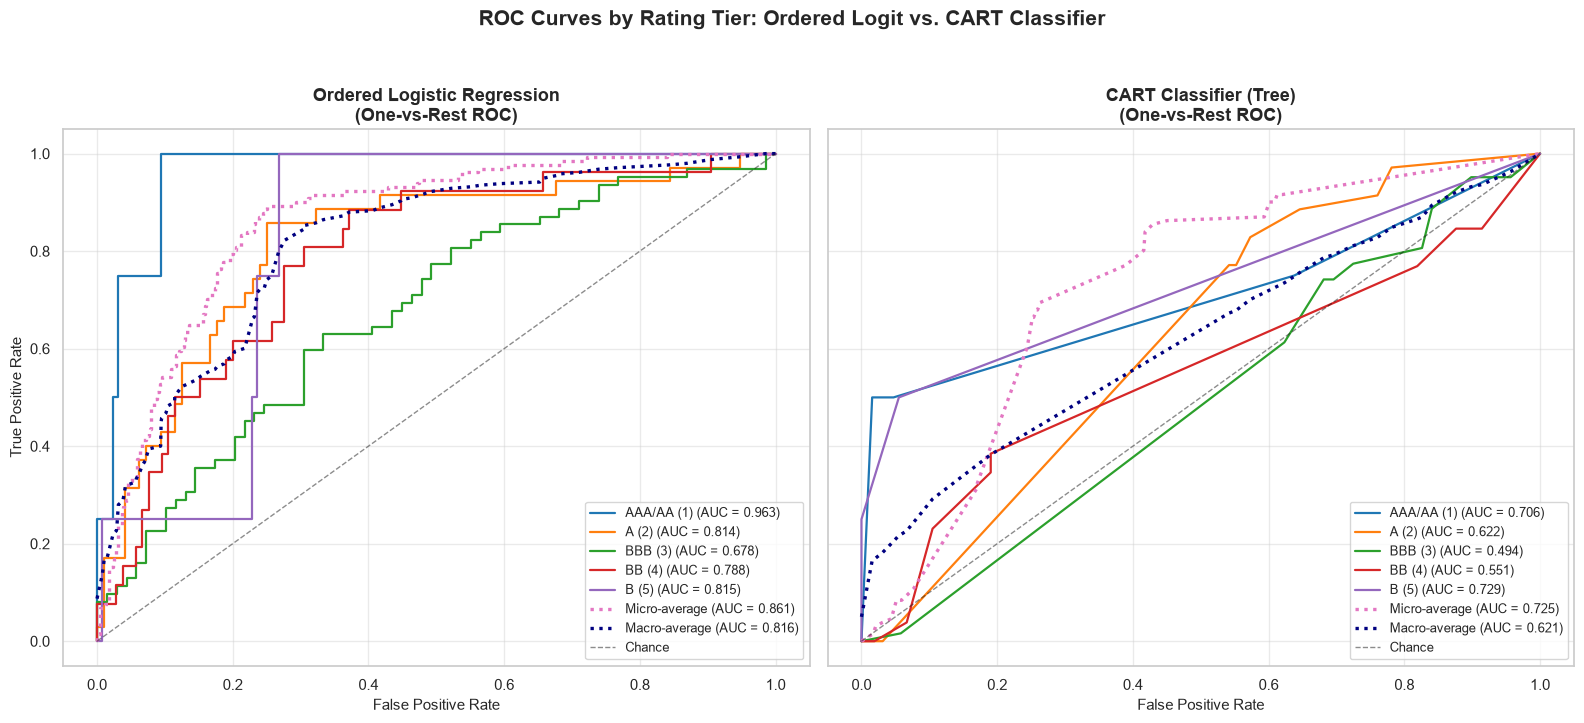


=== AUC SUMMARY TABLE (One-vs-Rest, Experiment 2: Broad Tiers) ===


,Ordered Logistic Regression,CART Classifier (Tree)
Rating Tier,,
AAA/AA (1),0.963,0.706
A (2),0.814,0.622
BBB (3),0.678,0.494
BB (4),0.788,0.551
B (5),0.815,0.729
Micro-average,0.861,0.725
Macro-average,0.816,0.621


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# -----------------------------------------------------------------------------
# 1. Prepare Probabilities & Ground Truth Binarization
# -----------------------------------------------------------------------------
classes = [1, 2, 3, 4, 5]
class_names = ['AAA/AA (1)', 'A (2)', 'BBB (3)', 'BB (4)', 'B (5)']
n_classes = len(classes)

# Binarize the multi-class test labels for One-vs-Rest evaluation
y_test_bin = label_binarize(y_test_b, classes=classes)

# Ordered Logistic Regression probabilities
probs_ord = ord_results.predict(X_test_scaled).values

# CART Classifier probabilities
probs_cart = cart_clf.predict_proba(X_test_scaled)

# -----------------------------------------------------------------------------
# 2. Compute ROC & AUC Helper Function
# -----------------------------------------------------------------------------
def get_roc_data(y_bin, y_score):
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
        
    # Micro-average ROC
    fpr["micro"], tpr["micro"], _ = roc_curve(y_bin.ravel(), y_score.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
    
    # Macro-average ROC
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= n_classes
    fpr["macro"] = all_fpr
    tpr["macro"] = mean_tpr
    roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])
    
    return fpr, tpr, roc_auc

fpr_ord, tpr_ord, auc_ord = get_roc_data(y_test_bin, probs_ord)
fpr_cart, tpr_cart, auc_cart = get_roc_data(y_test_bin, probs_cart)

# -----------------------------------------------------------------------------
# 3. Dual-Panel ROC Plot
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

# Panel 1: Ordered Logistic Regression
for i, color in zip(range(n_classes), colors):
    axes[0].plot(fpr_ord[i], tpr_ord[i], color=color, lw=1.6,
                 label=f'{class_names[i]} (AUC = {auc_ord[i]:.3f})')
axes[0].plot(fpr_ord["micro"], tpr_ord["micro"], color='#e377c2', lw=2.4, linestyle=':',
             label=f'Micro-average (AUC = {auc_ord["micro"]:.3f})')
axes[0].plot(fpr_ord["macro"], tpr_ord["macro"], color='#000080', lw=2.4, linestyle=':',
             label=f'Macro-average (AUC = {auc_ord["macro"]:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Chance')
axes[0].set_title('Ordered Logistic Regression\n(One-vs-Rest ROC)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('False Positive Rate', fontsize=11)
axes[0].set_ylabel('True Positive Rate', fontsize=11)
axes[0].legend(loc='lower right', fontsize=9)
axes[0].grid(True, linestyle='-', alpha=0.4)

# Panel 2: CART Classifier
for i, color in zip(range(n_classes), colors):
    axes[1].plot(fpr_cart[i], tpr_cart[i], color=color, lw=1.6,
                 label=f'{class_names[i]} (AUC = {auc_cart[i]:.3f})')
axes[1].plot(fpr_cart["micro"], tpr_cart["micro"], color='#e377c2', lw=2.4, linestyle=':',
             label=f'Micro-average (AUC = {auc_cart["micro"]:.3f})')
axes[1].plot(fpr_cart["macro"], tpr_cart["macro"], color='#000080', lw=2.4, linestyle=':',
             label=f'Macro-average (AUC = {auc_cart["macro"]:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Chance')
axes[1].set_title('CART Classifier (Tree)\n(One-vs-Rest ROC)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('False Positive Rate', fontsize=11)
axes[1].legend(loc='lower right', fontsize=9)
axes[1].grid(True, linestyle='-', alpha=0.4)

plt.suptitle('ROC Curves by Rating Tier: Ordered Logit vs. CART Classifier', fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

# -----------------------------------------------------------------------------
# 4. AUC Summary Table (Matching Reference Image)
# -----------------------------------------------------------------------------
auc_summary_data = []
for i in range(n_classes):
    auc_summary_data.append({
        'Rating Tier': class_names[i],
        'Ordered Logistic Regression': f"{auc_ord[i]:.3f}",
        'CART Classifier (Tree)': f"{auc_cart[i]:.3f}"
    })

auc_summary_data.append({
    'Rating Tier': 'Micro-average',
    'Ordered Logistic Regression': f"{auc_ord['micro']:.3f}",
    'CART Classifier (Tree)': f"{auc_cart['micro']:.3f}"
})

auc_summary_data.append({
    'Rating Tier': 'Macro-average',
    'Ordered Logistic Regression': f"{auc_ord['macro']:.3f}",
    'CART Classifier (Tree)': f"{auc_cart['macro']:.3f}"
})

auc_summary_df = pd.DataFrame(auc_summary_data).set_index('Rating Tier')

print("\n=== AUC SUMMARY TABLE (One-vs-Rest, Experiment 2: Broad Tiers) ===")
display(auc_summary_df)

Granular Rating Scale Experiment

In [20]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=DeprecationWarning)

In [21]:
#warnings
import warnings
warnings.filterwarnings('ignore')

# 1. Map S&P Letter Ratings to 16 Integer Notches
rating_rank_map = {
    'AAA': 1, 'AA+': 2, 'AA': 3, 'AA-': 4,
    'A+': 5, 'A': 6, 'A-': 7,
    'BBB+': 8, 'BBB': 9, 'BBB-': 10,
    'BB+': 11, 'BB': 12, 'BB-': 13,
    'B+': 14, 'B': 15, 'B-': 16
}

y_rank = df['S&P LT LC'].map(rating_rank_map)
y_train_rank = y_rank.loc[X_train.index]
y_test_rank = y_rank.loc[X_test.index]

# 2. Fit Granular Ordered Logistic Regression
ord_logit_g = OrderedModel(y_train_rank, X_train_scaled, distr='logit', hasconst=False)
ord_results_g = ord_logit_g.fit(method='bfgs', maxiter=1000, disp=False)

# 3. Predictions
prob_preds_rank = ord_results_g.predict(X_test_scaled)
unique_ranks = np.sort(y_train_rank.unique())
y_pred_rank = unique_ranks[np.argmax(prob_preds_rank.values, axis=1)]

# 4. Compute Metrics Across 16 Notches
exact_acc_g = accuracy_score(y_test_rank, y_pred_rank) * 100
bal_acc_g = balanced_accuracy_score(y_test_rank, y_pred_rank) * 100

# Pass the full label set explicitly so sklearn doesn't have to infer it
# from y_test alone -- this is what removes the pink UserWarning box
all_notch_labels = unique_ranks  # or np.arange(1, 17) for all 16 notches

macro_f1_g = f1_score(y_test_rank, y_pred_rank, labels=all_notch_labels, average='macro', zero_division=0) * 100
weighted_f1_g = f1_score(y_test_rank, y_pred_rank, labels=all_notch_labels, average='weighted', zero_division=0) * 100

hit_1_notch_ord = np.mean(np.abs(y_pred_rank - y_test_rank) <= 1) * 100
hit_2_notch_ord = np.mean(np.abs(y_pred_rank - y_test_rank) <= 2) * 100
print("=" * 65)
print("PERFORMANCE: ORDERED LOGISTIC REGRESSION (16 NOTCHES)")
print("=" * 65)
print(f"Exact Match Accuracy:      {exact_acc_g:.2f}%")
print(f"Balanced Accuracy:         {bal_acc_g:.2f}%")
print(f"Macro F1-Score:            {macro_f1_g:.2f}%")
print(f"Weighted F1-Score:         {weighted_f1_g:.2f}%")
print(f"Within ±1 Notch Tolerance: {hit_1_notch_ord:.2f}%")
print(f"Within ±2 Notch Tolerance: {hit_2_notch_ord:.2f}%")

PERFORMANCE: ORDERED LOGISTIC REGRESSION (16 NOTCHES)
Exact Match Accuracy:      32.06%
Balanced Accuracy:         21.54%
Macro F1-Score:            18.59%
Weighted F1-Score:         30.33%
Within ±1 Notch Tolerance: 66.41%
Within ±2 Notch Tolerance: 84.73%


CONFUSION MATRIX: GRANULAR ORDERED LOGIT (MAPPED TO 5 TIERS)


,AAA/AA (1),A (2),BBB (3),BB (4),B (5)
AAA/AA (1),1,3,0,0,0
A (2),0,18,14,3,0
BBB (3),0,7,39,16,0
BB (4),0,1,7,18,0
B (5),0,0,0,3,1


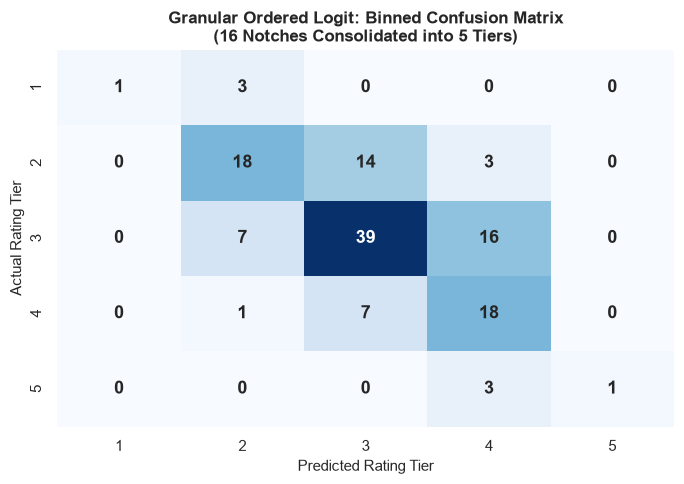


=== Comprehensive Metrics Table: Granular Ordered Logit ===


,Evaluation Dimension,Score
0,Exact Notch Accuracy (16 Notches),32.06%
1,Within ±1 Notch Tolerance Window,66.41%
2,Within ±2 Notches Tolerance Window,84.73%
3,Balanced Accuracy (16 Notches),21.54%
4,Consolidated 5-Tier Accuracy,58.78%
5,Consolidated 5-Tier Weighted F1,58.56%


In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.miscmodels.ordinal_model import OrderedModel
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    balanced_accuracy_score, f1_score
)

# -----------------------------------------------------------------------------
# 1. Map S&P Letter Ratings to 16 Integer Notches (1 = AAA to 16 = B-)
# -----------------------------------------------------------------------------
rating_rank_map = {
    'AAA': 1, 'AA+': 2, 'AA': 3, 'AA-': 4,
    'A+': 5, 'A': 6, 'A-': 7,
    'BBB+': 8, 'BBB': 9, 'BBB-': 10,
    'BB+': 11, 'BB': 12, 'BB-': 13,
    'B+': 14, 'B': 15, 'B-': 16
}

y_rank = df['S&P LT LC'].map(rating_rank_map)
y_train_rank = y_rank.loc[X_train.index]
y_test_rank = y_rank.loc[X_test.index]

# Fit Granular Ordered Logistic Regression
ord_logit_g = OrderedModel(y_train_rank, X_train_scaled, distr='logit', hasconst=False)
ord_results_g = ord_logit_g.fit(method='bfgs', maxiter=1000, disp=False)

# Out-of-sample notch predictions
prob_preds_rank = ord_results_g.predict(X_test_scaled)
unique_ranks = np.sort(y_train_rank.unique())
y_pred_rank = unique_ranks[np.argmax(prob_preds_rank.values, axis=1)]

# -----------------------------------------------------------------------------
# 2. Map Notches into the 5 Broad Tiers (Readable 5x5 Matrix)
# -----------------------------------------------------------------------------
# Notches 1-4: Tier 1 (AAA/AA) | 5-7: Tier 2 (A) | 8-10: Tier 3 (BBB)
# Notches 11-13: Tier 4 (BB)  | 14-16: Tier 5 (B)
def map_notch_to_tier(series):
    return pd.cut(
        series,
        bins=[0, 4, 7, 10, 13, 20],
        labels=[1, 2, 3, 4, 5]
    ).astype(int)

y_test_ord_tier = map_notch_to_tier(y_test_rank)
y_pred_ord_tier = map_notch_to_tier(pd.Series(y_pred_rank, index=y_test_rank.index))

tier_names = ['AAA/AA (1)', 'A (2)', 'BBB (3)', 'BB (4)', 'B (5)']
tier_labels = [1, 2, 3, 4, 5]

cm_ord_granular_binned = confusion_matrix(y_test_ord_tier, y_pred_ord_tier, labels=tier_labels)

print("=" * 70)
print("CONFUSION MATRIX: GRANULAR ORDERED LOGIT (MAPPED TO 5 TIERS)")
print("=" * 70)
display(pd.DataFrame(cm_ord_granular_binned, index=tier_names, columns=tier_names))

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm_ord_granular_binned,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=tier_labels,
    yticklabels=tier_labels,
    annot_kws={'size': 13, 'weight': 'bold'}
)
plt.title('Granular Ordered Logit: Binned Confusion Matrix\n(16 Notches Consolidated into 5 Tiers)', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Rating Tier', fontsize=11)
plt.ylabel('Actual Rating Tier', fontsize=11)
plt.tight_layout()
plt.show()

# -----------------------------------------------------------------------------
# 3. Comprehensive Performance Metrics
# -----------------------------------------------------------------------------
exact_acc_g = accuracy_score(y_test_rank, y_pred_rank) * 100
bal_acc_g = balanced_accuracy_score(y_test_rank, y_pred_rank) * 100
hit_1_notch_ord = np.mean(np.abs(y_pred_rank - y_test_rank) <= 1) * 100
hit_2_notch_ord = np.mean(np.abs(y_pred_rank - y_test_rank) <= 2) * 100

binned_acc_ord = accuracy_score(y_test_ord_tier, y_pred_ord_tier) * 100
binned_f1_ord = f1_score(y_test_ord_tier, y_pred_ord_tier, average='weighted', zero_division=0) * 100

metrics_granular_df = pd.DataFrame({
    'Evaluation Dimension': [
        'Exact Notch Accuracy (16 Notches)',
        'Within ±1 Notch Tolerance Window',
        'Within ±2 Notches Tolerance Window',
        'Balanced Accuracy (16 Notches)',
        'Consolidated 5-Tier Accuracy',
        'Consolidated 5-Tier Weighted F1'
    ],
    'Score': [
        f"{exact_acc_g:.2f}%",
        f"{hit_1_notch_ord:.2f}%",
        f"{hit_2_notch_ord:.2f}%",
        f"{bal_acc_g:.2f}%",
        f"{binned_acc_ord:.2f}%",
        f"{binned_f1_ord:.2f}%"
    ]
})

print("\n=== Comprehensive Metrics Table: Granular Ordered Logit ===")
display(metrics_granular_df)

In [23]:
#Granular Ordered Logistic Regression — Traditional Econometric Table
params_g = ord_results_g.params
conf_g = ord_results_g.conf_int()
bse_g = ord_results_g.bse
pvalues_g = ord_results_g.pvalues

excel_display_granular = pd.DataFrame({
    'Variable': params_g.index,
    'Coefficient (Beta)': params_g.values,
    'Std. Error': bse_g.values,
    'z-Statistic': (params_g / bse_g).values,
    'p-value': pvalues_g.values,
    '[95% Conf. Interval Lower]': conf_g[0].values,
    '[95% Conf. Interval Upper]': conf_g[1].values,
    'Odds Ratio (exp(-Beta))': np.exp(-params_g.values)
}).round(4)

print("=" * 80)
print("TRADITIONAL ECONOMETRIC REGRESSION DISPLAY: GRANULAR NOTCH SCALE (1-16)")
print("=" * 80)
display(excel_display_granular)

# Save to Excel
excel_display_granular.to_excel("econometric_table_ordered_logit_granular.xlsx", index=False)

TRADITIONAL ECONOMETRIC REGRESSION DISPLAY: GRANULAR NOTCH SCALE (1-16)


,Variable,Coefficient (Beta),Std. Error,z-Statistic,p-value,[95% Conf. Interval Lower],[95% Conf. Interval Upper],Odds Ratio (exp(-Beta))
0,Net Sales - 5 Yr Geo Gr,0.27,0.08,3.48,0.00,0.12,0.43,0.76
1,Mkt Cap,-0.88,0.09,-9.68,0.00,-1.05,-0.70,2.40
2,Tot Assets,-0.43,0.06,-7.66,0.00,-0.54,-0.32,1.53
3,Curr Ratio,0.27,0.10,2.57,0.01,0.06,0.47,0.77
4,Debt/Assets,0.31,0.14,2.22,0.03,0.04,0.59,0.73
5,5Yr Avg ROE,-0.07,0.03,-2.42,0.02,-0.12,-0.01,1.07
6,ROA - 5 Yr Geo Gr,0.15,0.05,2.92,0.00,0.05,0.26,0.86
7,ROA,-0.19,0.11,-1.76,0.08,-0.40,0.02,1.21
8,EBITDA / Iexp,-0.01,0.03,-0.41,0.68,-0.06,0.04,1.01
9,Debt/EBITDA,0.02,0.08,0.21,0.84,-0.14,0.17,0.98


In [24]:
#Granular CART Regressor
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, balanced_accuracy_score, f1_score
)

# 1. Fit CART Regressor on Continuous Granular Scores
cart_reg = DecisionTreeRegressor(max_depth=5, random_state=42)
cart_reg.fit(X_train_scaled, y_train_g)
y_pred_cart_cont = cart_reg.predict(X_test_scaled)

# 2. Snap continuous predictions to the nearest unique granular notches
unique_notches = np.sort(y_test_g.unique())
y_pred_cart_granular = np.array([unique_notches[np.abs(unique_notches - p).argmin()] for p in y_pred_cart_cont])

# 3. Compute Granular Classification & Tolerance Metrics
exact_acc_cart = accuracy_score(y_test_g, y_pred_cart_granular)
bal_acc_cart = balanced_accuracy_score(y_test_g, y_pred_cart_granular)
macro_f1_cart = f1_score(y_test_g, y_pred_cart_granular, average='macro', zero_division=0)
weighted_f1_cart = f1_score(y_test_g, y_pred_cart_granular, average='weighted', zero_division=0)

y_test_idx = np.array([np.where(unique_notches == x)[0][0] for x in y_test_g])
y_pred_idx = np.array([np.where(unique_notches == p)[0][0] for p in y_pred_cart_granular])

within_1_notch = np.mean(np.abs(y_pred_idx - y_test_idx) <= 1) * 100
within_2_notch = np.mean(np.abs(y_pred_idx - y_test_idx) <= 2) * 100

print("=" * 65)
print("PERFORMANCE: CART REGRESSOR (GRANULAR NOTCHES)")
print("=" * 65)
print(f"Exact Match Accuracy:        {exact_acc_cart * 100:.2f}%")
print(f"Balanced Accuracy:           {bal_acc_cart * 100:.2f}%")
print(f"Macro F1-Score:              {macro_f1_cart * 100:.2f}%")
print(f"Weighted F1-Score:           {weighted_f1_cart * 100:.2f}%")
print(f"Within ±1 Notch Tolerance:   {within_1_notch:.2f}%")
print(f"Within ±2 Notch Tolerance:   {within_2_notch:.2f}%")

PERFORMANCE: CART REGRESSOR (GRANULAR NOTCHES)
Exact Match Accuracy:        25.19%
Balanced Accuracy:           14.74%
Macro F1-Score:              14.94%
Weighted F1-Score:           24.41%
Within ±1 Notch Tolerance:   61.83%
Within ±2 Notch Tolerance:   82.44%


CONFUSION MATRIX: CART REGRESSOR (GRANULAR NOTCHES)


,3,4,5,6,7,8,9,10,11,12,13,14,15
3,0,0,1,0,1,0,0,0,0,0,0,0,0
4,1,0,1,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,2,1,0,0,0,0,0,0,0
6,0,0,3,1,2,3,2,1,0,0,0,0,0
7,0,0,1,1,6,7,3,2,0,0,0,0,0
8,0,0,0,0,4,5,5,2,0,1,0,1,0
9,0,0,0,2,4,2,12,6,2,1,0,0,0
10,0,0,0,0,2,2,6,3,1,1,0,0,0
11,0,0,0,0,0,1,3,2,4,1,0,0,0
12,0,0,0,0,1,1,1,1,4,1,0,0,0


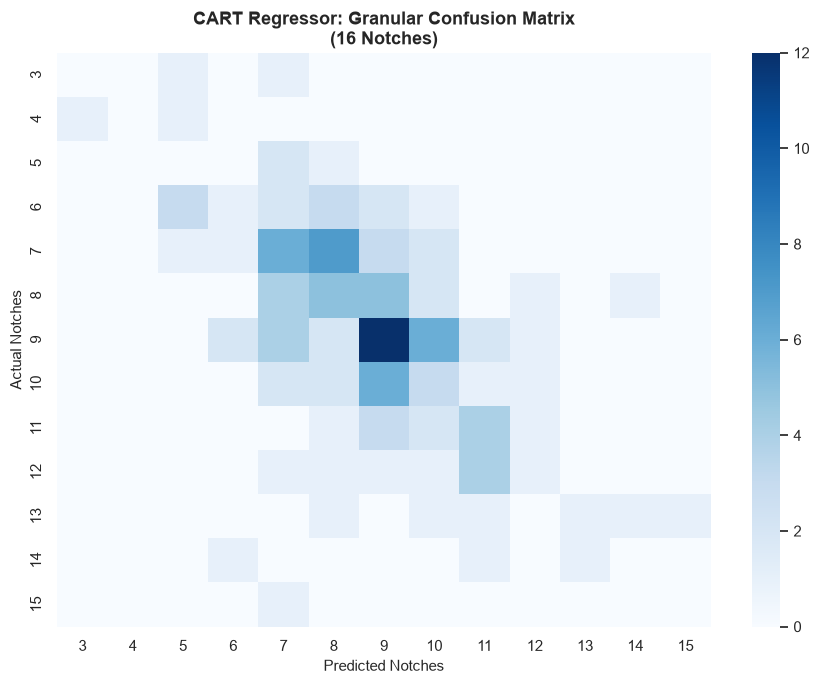

CLASSIFICATION REPORT: CART REGRESSOR (GRANULAR NOTCHES)
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00         2
           5       0.00      0.00      0.00         3
           6       0.20      0.08      0.12        12
           7       0.26      0.30      0.28        20
           8       0.22      0.28      0.24        18
           9       0.38      0.41      0.39        29
          10       0.17      0.20      0.18        15
          11       0.31      0.36      0.33        11
          12       0.20      0.11      0.14         9
          13       0.50      0.17      0.25         6
          14       0.00      0.00      0.00         3
          15       0.00      0.00      0.00         1

    accuracy                           0.25       131
   macro avg       0.17      0.15      0.15       131
weighted avg       0.25      0.25      0.24       131

=== Comprehensive Metr

,Metric,Score
0,R² Score,0.2585
1,Mean Absolute Error (MAE),1.4852
2,RMSE,2.0192
3,Exact Match Accuracy,25.19%
4,Balanced Accuracy,14.74%
5,Weighted F1-Score,24.41%
6,Within ±1 Notch Tolerance,61.83%
7,Within ±2 Notch Tolerance,82.44%


In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    confusion_matrix, classification_report,
    accuracy_score, balanced_accuracy_score, f1_score
)

# 1. Fit CART Regressor on Continuous Granular Scores
cart_reg = DecisionTreeRegressor(max_depth=5, random_state=42)
cart_reg.fit(X_train_scaled, y_train_g)
y_pred_cart_cont = cart_reg.predict(X_test_scaled)

# Regression Metrics
mae_cart = mean_absolute_error(y_test_g, y_pred_cart_cont)
rmse_cart = np.sqrt(mean_squared_error(y_test_g, y_pred_cart_cont))
r2_cart = r2_score(y_test_g, y_pred_cart_cont)

# 2. Snap continuous predictions to the nearest unique granular notches
unique_notches = np.sort(y_test_g.unique())
y_pred_cart_granular = np.array([unique_notches[np.abs(unique_notches - p).argmin()] for p in y_pred_cart_cont])

# 3. Confusion Matrix & Heatmap
cm_cart_granular = confusion_matrix(y_test_g, y_pred_cart_granular, labels=unique_notches)

print("=" * 65)
print("CONFUSION MATRIX: CART REGRESSOR (GRANULAR NOTCHES)")
print("=" * 65)
display(pd.DataFrame(cm_cart_granular, index=unique_notches, columns=unique_notches))

plt.figure(figsize=(9, 7))
sns.heatmap(
    cm_cart_granular, annot=False, fmt='d', cmap='Blues', cbar=True,
    xticklabels=unique_notches, yticklabels=unique_notches
)
plt.title('CART Regressor: Granular Confusion Matrix\n(16 Notches)', fontsize=13, fontweight='bold')
plt.xlabel('Predicted Notches', fontsize=11)
plt.ylabel('Actual Notches', fontsize=11)
plt.tight_layout()
plt.show()

# 4. Classification Report
print("=" * 65)
print("CLASSIFICATION REPORT: CART REGRESSOR (GRANULAR NOTCHES)")
print("=" * 65)
print(classification_report(y_test_g, y_pred_cart_granular, zero_division=0))

# 5. Metrics Table & Tolerances
exact_acc_cart = accuracy_score(y_test_g, y_pred_cart_granular)
bal_acc_cart = balanced_accuracy_score(y_test_g, y_pred_cart_granular)
weighted_f1_cart = f1_score(y_test_g, y_pred_cart_granular, average='weighted', zero_division=0)

y_test_idx = np.array([np.where(unique_notches == x)[0][0] for x in y_test_g])
y_pred_idx = np.array([np.where(unique_notches == p)[0][0] for p in y_pred_cart_granular])

within_1_notch = np.mean(np.abs(y_pred_idx - y_test_idx) <= 1) * 100
within_2_notch = np.mean(np.abs(y_pred_idx - y_test_idx) <= 2) * 100

metrics_cart_granular_df = pd.DataFrame({
    'Metric': [
        'R² Score', 'Mean Absolute Error (MAE)', 'RMSE',
        'Exact Match Accuracy', 'Balanced Accuracy', 'Weighted F1-Score',
        'Within ±1 Notch Tolerance', 'Within ±2 Notch Tolerance'
    ],
    'Score': [
        f"{r2_cart:.4f}", f"{mae_cart:.4f}", f"{rmse_cart:.4f}",
        f"{exact_acc_cart * 100:.2f}%", f"{bal_acc_cart * 100:.2f}%", f"{weighted_f1_cart * 100:.2f}%",
        f"{within_1_notch:.2f}%", f"{within_2_notch:.2f}%"
    ]
})

print("=== Comprehensive Metrics Table: CART Regressor (Granular) ===")
display(metrics_cart_granular_df)

y_test_g          -> min=3.000, max=15.000, NaNs=0
y_pred_cart_granular -> min=3.000, max=15.000, NaNs=0
CONFUSION MATRIX: CART REGRESSOR (GRANULAR BINNED TO TIERS)


,AAA/AA (1),A (2),BBB (3),BB (4),B (5)
AAA/AA (1),1,3,0,0,0
A (2),0,16,19,0,0
BBB (3),0,12,43,6,1
BB (4),0,1,11,12,2
B (5),0,2,0,2,0


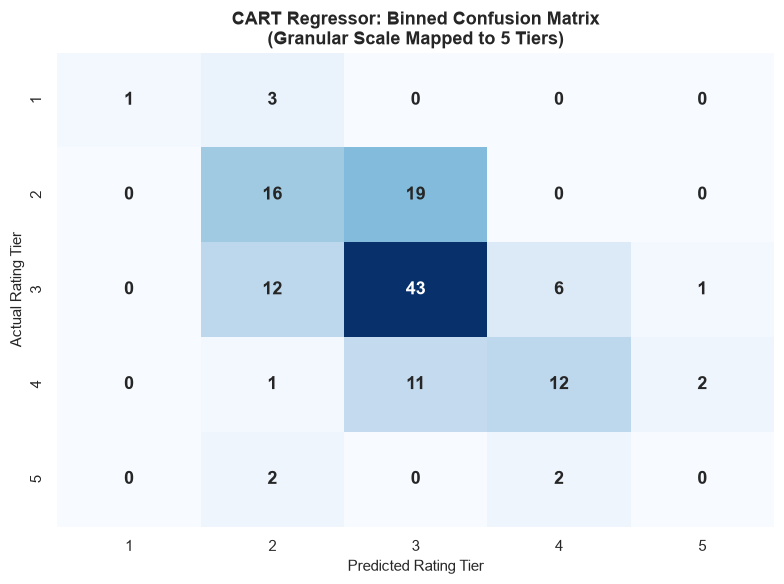


CLASSIFICATION REPORT: CART REGRESSOR
              precision    recall  f1-score   support

  AAA/AA (1)       1.00      0.25      0.40         4
       A (2)       0.47      0.46      0.46        35
     BBB (3)       0.59      0.69      0.64        62
      BB (4)       0.60      0.46      0.52        26
       B (5)       0.00      0.00      0.00         4

    accuracy                           0.55       131
   macro avg       0.53      0.37      0.40       131
weighted avg       0.55      0.55      0.54       131


=== Comprehensive Metrics Table ===


,Metric,Score
0,Accuracy,54.96%
1,Balanced Accuracy,37.24%
2,Macro Precision,53.19%
3,Macro Recall,37.24%
4,Macro F1-Score,40.45%
5,Weighted Precision,55.41%
6,Weighted Recall,54.96%
7,Weighted F1-Score,54.12%
8,±1 Notch Hit Rate (Continuous),17.56%


In [26]:
# -------------------------------------------------------------
# 1. Map Granular Predictions & Ground Truth to Discrete Tiers
# -------------------------------------------------------------
# Rating Scale here is on the 1-16 notch scale (AAA=1 ... B-=16),
# Notches 1-4: Tier 1 (AAA/AA) | 5-7: Tier 2 (A) | 8-10: Tier 3 (BBB)
# Notches 11-13: Tier 4 (BB)  | 14-16: Tier 5 (B/CCC)
bins = [0, 4, 7, 10, 13, 20]
tier_classes = [1, 2, 3, 4, 5]
tier_labels = ['AAA/AA (1)', 'A (2)', 'BBB (3)', 'BB (4)', 'B (5)']

print(f"y_test_g          -> min={y_test_g.min():.3f}, max={y_test_g.max():.3f}, NaNs={y_test_g.isna().sum()}")
print(f"y_pred_cart_granular -> min={np.min(y_pred_cart_granular):.3f}, max={np.max(y_pred_cart_granular):.3f}, NaNs={pd.isna(y_pred_cart_granular).sum()}")

y_test_g_binned = pd.cut(y_test_g, bins=bins, labels=tier_classes).astype(int)
y_pred_cart_g_binned = pd.cut(y_pred_cart_granular, bins=bins, labels=tier_classes).astype(int)

# -------------------------------------------------------------
# 2. Compute Confusion Matrix
# -------------------------------------------------------------
cm_cart_reg = confusion_matrix(y_test_g_binned, y_pred_cart_g_binned, labels=tier_classes)

print("=" * 65)
print("CONFUSION MATRIX: CART REGRESSOR (GRANULAR BINNED TO TIERS)")
print("=" * 65)
display(pd.DataFrame(cm_cart_reg, index=tier_labels, columns=tier_labels))

# -------------------------------------------------------------
# 3. Plot Confusion Matrix Heatmap
# -------------------------------------------------------------
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_cart_reg,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=['1', '2', '3', '4', '5'],
    yticklabels=['1', '2', '3', '4', '5'],
    annot_kws={'size': 13, 'weight': 'bold'}
)
plt.title('CART Regressor: Binned Confusion Matrix\n(Granular Scale Mapped to 5 Tiers)', fontsize=13, fontweight='bold')
plt.xlabel('Predicted Rating Tier', fontsize=11)
plt.ylabel('Actual Rating Tier', fontsize=11)
plt.tight_layout()
plt.show()

# -------------------------------------------------------------
# 4. Detailed Classification Report (Precision, Recall, F1)
# -------------------------------------------------------------
print("\n" + "=" * 65)
print("CLASSIFICATION REPORT: CART REGRESSOR")
print("=" * 65)
print(classification_report(
    y_test_g_binned, y_pred_cart_g_binned,
    labels=tier_classes, target_names=tier_labels, zero_division=0
))

# -------------------------------------------------------------
# 5. Overall Model Metrics Table
# -------------------------------------------------------------
metrics_cart_reg = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'Balanced Accuracy',
        'Macro Precision',
        'Macro Recall',
        'Macro F1-Score',
        'Weighted Precision',
        'Weighted Recall',
        'Weighted F1-Score',
        '±1 Notch Hit Rate (Continuous)'
    ],
    'Score': [
        f"{accuracy_score(y_test_g_binned, y_pred_cart_g_binned) * 100:.2f}%",
        f"{balanced_accuracy_score(y_test_g_binned, y_pred_cart_g_binned) * 100:.2f}%",
        f"{precision_score(y_test_g_binned, y_pred_cart_g_binned, average='macro', zero_division=0) * 100:.2f}%",
        f"{recall_score(y_test_g_binned, y_pred_cart_g_binned, average='macro', zero_division=0) * 100:.2f}%",
        f"{f1_score(y_test_g_binned, y_pred_cart_g_binned, average='macro', zero_division=0) * 100:.2f}%",
        f"{precision_score(y_test_g_binned, y_pred_cart_g_binned, average='weighted', zero_division=0) * 100:.2f}%",
        f"{recall_score(y_test_g_binned, y_pred_cart_g_binned, average='weighted', zero_division=0) * 100:.2f}%",
        f"{f1_score(y_test_g_binned, y_pred_cart_g_binned, average='weighted', zero_division=0) * 100:.2f}%",
        f"{np.mean(np.abs(y_pred_cart_cont - y_test_g) <= 0.33) * 100:.2f}%"
    ]
})

print("\n=== Comprehensive Metrics Table ===")
display(metrics_cart_reg)

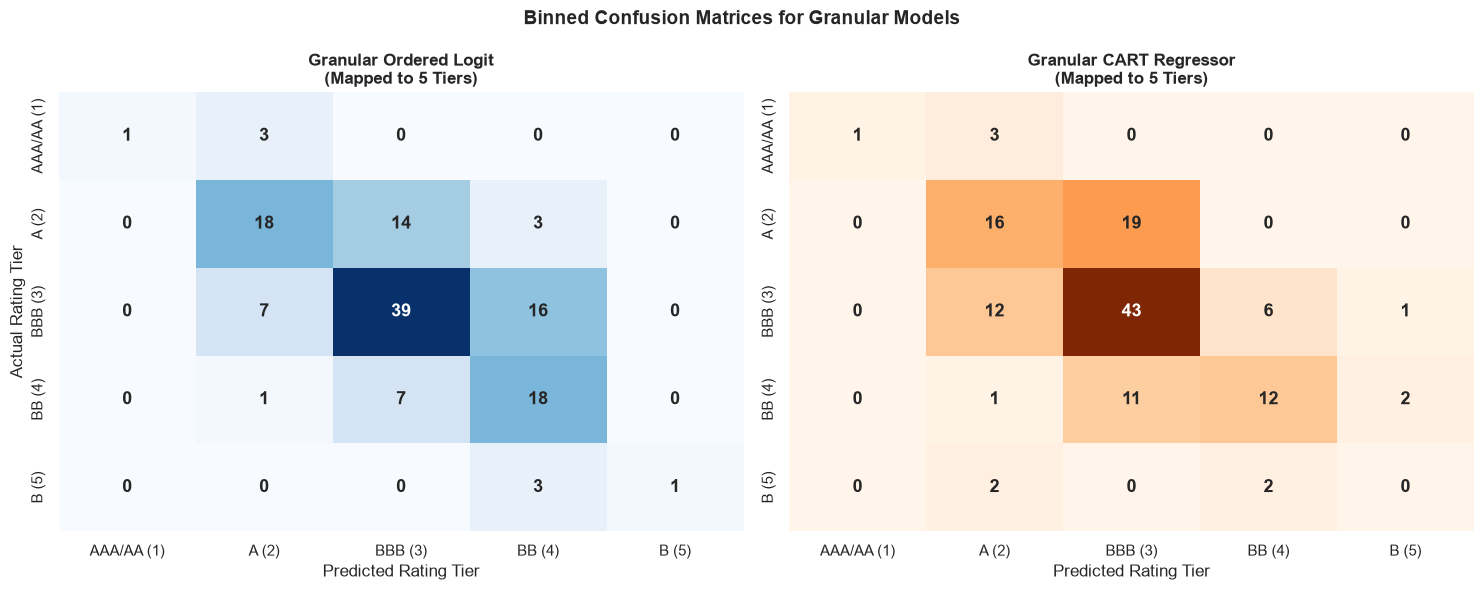


MASTER MODEL BENCHMARK: SYNTHESIS ACROSS ALL MODEL CONFIGURATIONS


,Target Scale,Model Architecture,Mapped Accuracy,Balanced Accuracy,Weighted F1-Score
0,Broad (Tiers 1-5),Ordered Logistic Regression,55.73%,38.96%,54.64%
1,Broad (Tiers 1-5),CART Classifier (Tree),32.06%,43.44%,23.11%
2,Granular (Mapped to Tiers),Ordered Logistic Regression,58.78%,46.71%,58.56%
3,Granular (Mapped to Tiers),CART Regressor (Tree),54.96%,37.24%,54.12%


In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, balanced_accuracy_score, f1_score

# 1. Fix Bins using Infinity to prevent NaN crashes
tier_labels = [1, 2, 3, 4, 5]
tier_names = ['AAA/AA (1)', 'A (2)', 'BBB (3)', 'BB (4)', 'B (5)']

# Extend boundaries to catch any extreme predicted outliers
bins_ord = [-np.inf, 4.0, 7.0, 10.0, 13.0, np.inf]
bins_reg = [-np.inf, 1.835, 2.665, 3.505, 4.335, np.inf]


# 1. Define the unified 16-Notch boundaries
# Notches 1-4 (Tier 1) | 5-7 (Tier 2) | 8-10 (Tier 3) | 11-13 (Tier 4) | 14-16 (Tier 5)
bins_16_scale = [-np.inf, 4.0, 7.0, 10.0, 13.0, np.inf]
tier_labels = [1, 2, 3, 4, 5]

# 2. Bin the actuals and BOTH sets of predictions using the same 16-notch boundaries
y_test_tier = pd.cut(y_test_rank, bins=bins_16_scale, labels=tier_labels).astype(int)

# Use your 1-16 predictions for Ordered Logit
y_pred_g_ord_binned = pd.cut(y_pred_rank, bins=bins_16_scale, labels=tier_labels).astype(int)

# Use your 1-16 predictions for CART Regressor
y_pred_cart_g_binned = pd.cut(y_pred_cart_granular, bins=bins_16_scale, labels=tier_labels).astype(int)



# 2. Generate Confusion Matrices
cm_g_ord = confusion_matrix(y_test_tier, y_pred_g_ord_binned, labels=tier_labels)
cm_cart_reg = confusion_matrix(y_test_tier, y_pred_cart_g_binned, labels=tier_labels)

# 3. Plot Side-by-Side Heatmaps for Granular Models Mapped to Tiers
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.heatmap(cm_g_ord, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0],
            xticklabels=tier_names, yticklabels=tier_names, annot_kws={'size': 13, 'weight': 'bold'})
axes[0].set_title('Granular Ordered Logit\n(Mapped to 5 Tiers)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted Rating Tier')
axes[0].set_ylabel('Actual Rating Tier')

sns.heatmap(cm_cart_reg, annot=True, fmt='d', cmap='Oranges', cbar=False, ax=axes[1],
            xticklabels=tier_names, yticklabels=tier_names, annot_kws={'size': 13, 'weight': 'bold'})
axes[1].set_title('Granular CART Regressor\n(Mapped to 5 Tiers)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted Rating Tier')

plt.suptitle('Binned Confusion Matrices for Granular Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 4. Master 4-Model Benchmark Table
# Format y_test_b to a 1D array if needed for the broad model metrics
y_test_b_clean = np.asarray(y_test_b).ravel()

master_df = pd.DataFrame({
    'Target Scale': [
        'Broad (Tiers 1-5)',
        'Broad (Tiers 1-5)',
        'Granular (Mapped to Tiers)',
        'Granular (Mapped to Tiers)'
    ],
    'Model Architecture': [
        'Ordered Logistic Regression',
        'CART Classifier (Tree)',
        'Ordered Logistic Regression',
        'CART Regressor (Tree)'
    ],
    'Mapped Accuracy': [
        f"{accuracy_score(y_test_b_clean, y_pred_ord_b)*100:.2f}%",
        f"{accuracy_score(y_test_b_clean, y_pred_cart_b)*100:.2f}%",
        f"{accuracy_score(y_test_tier, y_pred_g_ord_binned)*100:.2f}%",
        f"{accuracy_score(y_test_tier, y_pred_cart_g_binned)*100:.2f}%"
    ],
    'Balanced Accuracy': [
        f"{balanced_accuracy_score(y_test_b_clean, y_pred_ord_b)*100:.2f}%",
        f"{balanced_accuracy_score(y_test_b_clean, y_pred_cart_b)*100:.2f}%",
        f"{balanced_accuracy_score(y_test_tier, y_pred_g_ord_binned)*100:.2f}%",
        f"{balanced_accuracy_score(y_test_tier, y_pred_cart_g_binned)*100:.2f}%"
    ],
    'Weighted F1-Score': [
        f"{f1_score(y_test_b_clean, y_pred_ord_b, average='weighted', zero_division=0)*100:.2f}%",
        f"{f1_score(y_test_b_clean, y_pred_cart_b, average='weighted', zero_division=0)*100:.2f}%",
        f"{f1_score(y_test_tier, y_pred_g_ord_binned, average='weighted', zero_division=0)*100:.2f}%",
        f"{f1_score(y_test_tier, y_pred_cart_g_binned, average='weighted', zero_division=0)*100:.2f}%"
    ]
})

print("\n" + "=" * 90)
print("MASTER MODEL BENCHMARK: SYNTHESIS ACROSS ALL MODEL CONFIGURATIONS")
print("=" * 90)
display(master_df)